# Local XAI Analysis — Employee Attrition

This notebook provides **local (instance-level) explanations** for the SVM blackbox models trained on the IBM HR Attrition dataset. We compare explanations across two preprocessing strategies:

- **Full-column (full_col):** All raw features retained — richer explanations, more HR-actionable
- **Reduced-column (rm_col):** High-VIF / redundant features removed — sparser but potentially more stable

## Methods

| Method | What it shows | Output type |
|--------|--------------|-------------|
| **ICE** | How a single prediction changes as one feature varies | Curve per instance |
| **SHAP** | Per-feature contribution to an individual prediction | Waterfall / Force plot |
| **Anchors** | Sufficient if-then rule that guarantees the prediction | Rule with precision & coverage |
| **DiCE** | Minimal feature changes that would flip the prediction | Counterfactual table + HR actions |

## Sample Selection

We select **8 representative employees** from the test set (2 per confusion-matrix quadrant: TP, FP, FN, TN) and explain each through all four methods, enabling cross-method and cross-model comparison.

## Section 0: Setup, Data Loading & Model Preparation

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.inspection import PartialDependenceDisplay

import shap
import dice_ml
from alibi.explainers import AnchorTabular

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13

In [2]:
# ── Load raw data ──
df_raw = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
y_all = df_raw["Attrition"].map({"Yes": 1, "No": 0})

# ── Full-column feature set (all features except target) ──
X_full_all = df_raw.drop(columns=["Attrition"]).copy()

# ── Reduced-column feature set (remove high-VIF / constant / ID columns) ──
cols_to_remove = [
    "EmployeeCount", "StandardHours", "EmployeeNumber", "Over18",
    "JobLevel", "YearsAtCompany", "WorkLifeBalance", "MonthlyIncome",
    "PerformanceRating", "JobInvolvement", "HourlyRate", "DailyRate",
]
X_rm_all = df_raw.drop(columns=["Attrition"] + cols_to_remove, errors="ignore").copy()

print(f"Full-col features: {X_full_all.shape[1]}  |  Rm-col features: {X_rm_all.shape[1]}")
print(f"Total samples: {len(y_all)}  |  Attrition rate: {y_all.mean():.2%}")

Full-col features: 34  |  Rm-col features: 22
Total samples: 1470  |  Attrition rate: 16.12%


In [3]:
# ── Train / Validation / Test split (60 / 20 / 20, stratified) ──
# Identical to the modelling pipeline notebooks for reproducibility.

def split_data(X, y, random_state=RANDOM_STATE):
    """Return X_train, X_val, X_test, y_train, y_val, y_test (60/20/20)."""
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=random_state,
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=random_state,
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

# Full-col split
X_train_fc, X_val_fc, X_test_fc, y_train_fc, y_val_fc, y_test_fc = split_data(X_full_all, y_all)
# Rm-col split
X_train_rm, X_val_rm, X_test_rm, y_train_rm, y_val_rm, y_test_rm = split_data(X_rm_all, y_all)

# Feature type detection (based on training set)
num_features_fc = X_train_fc.select_dtypes(include=["number"]).columns.tolist()
cat_features_fc = X_train_fc.select_dtypes(exclude=["number"]).columns.tolist()
num_features_rm = X_train_rm.select_dtypes(include=["number"]).columns.tolist()
cat_features_rm = X_train_rm.select_dtypes(exclude=["number"]).columns.tolist()

print("Split summary:")
for label, Xtr, Xv, Xt in [
    ("Full-col", X_train_fc, X_val_fc, X_test_fc),
    ("Rm-col",   X_train_rm, X_val_rm, X_test_rm),
]:
    print(f"  {label}: train={Xtr.shape}, val={Xv.shape}, test={Xt.shape}")

Split summary:
  Full-col: train=(882, 34), val=(294, 34), test=(294, 34)
  Rm-col: train=(882, 22), val=(294, 22), test=(294, 22)


### Model Loading

We attempt to load the pre-trained models from joblib files saved by the modelling team. If sklearn version mismatch prevents loading, we retrain locally using the **exact same hyperparameters** (extracted from the original models) to ensure reproducibility.

In [4]:
def build_svm_pipeline(numeric_features, categorical_features, C, gamma):
    """Build an SVM pipeline identical to the modelling notebooks."""
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), numeric_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]), categorical_features),
        ]
    )
    return Pipeline([
        ("prep", preprocessor),
        ("model", SVC(
            kernel="rbf", C=C, gamma=gamma,
            class_weight="balanced", probability=True,
            random_state=RANDOM_STATE,
        )),
    ])


def load_or_retrain(joblib_path, X_train, y_train, X_test, y_test,
                     numeric_features, categorical_features, C, gamma, label):
    """Try loading from joblib; fall back to local retraining with known params."""
    try:
        model = joblib.load(joblib_path)
        # Quick sanity check — force a predict call
        model.predict_proba(X_test[:1])
        print(f"[{label}] Loaded from {joblib_path}")
    except Exception as e:
        print(f"[{label}] Joblib load failed ({type(e).__name__}), retraining with known params...")
        model = build_svm_pipeline(numeric_features, categorical_features, C, gamma)
        model.fit(X_train, y_train)
        print(f"[{label}] Retrained successfully.")
    return model


# Load / retrain both models
svm_fc = load_or_retrain(
    "full_col_best_overall_blackbox_svm.joblib",
    X_train_fc, y_train_fc, X_test_fc, y_test_fc,
    num_features_fc, cat_features_fc,
    C=0.5, gamma=0.01, label="Full-col SVM",
)

svm_rm = load_or_retrain(
    "rm_col_recommended_blackbox_svm.joblib",
    X_train_rm, y_train_rm, X_test_rm, y_test_rm,
    num_features_rm, cat_features_rm,
    C=2, gamma=0.01, label="Rm-col SVM",
)

[Full-col SVM] Joblib load failed (AttributeError), retraining with known params...
[Full-col SVM] Retrained successfully.
[Rm-col SVM] Joblib load failed (AttributeError), retraining with known params...
[Rm-col SVM] Retrained successfully.


In [5]:
# ── Threshold tuning on validation set (F2 score, same as modelling notebooks) ──

def tune_threshold(model, X_val, y_val, grid=np.linspace(0.20, 0.80, 61)):
    """Find the threshold that maximises F2 on the validation set."""
    proba = model.predict_proba(X_val)[:, 1]
    best_t, best_f2 = 0.5, 0.0
    for t in grid:
        preds = (proba >= t).astype(int)
        f2 = fbeta_score(y_val, preds, beta=2, zero_division=0)
        if f2 > best_f2:
            best_t, best_f2 = t, f2
    return float(best_t), best_f2

threshold_fc, f2_fc = tune_threshold(svm_fc, X_val_fc, y_val_fc)
threshold_rm, f2_rm = tune_threshold(svm_rm, X_val_rm, y_val_rm)

print(f"Full-col SVM — optimal threshold: {threshold_fc:.2f} (val F2={f2_fc:.3f})")
print(f"Rm-col   SVM — optimal threshold: {threshold_rm:.2f} (val F2={f2_rm:.3f})")

Full-col SVM — optimal threshold: 0.34 (val F2=0.628)
Rm-col   SVM — optimal threshold: 0.23 (val F2=0.613)


In [6]:
# ── Quick sanity check: test-set performance ──

for label, model, X_test, y_test, thr in [
    ("Full-col", svm_fc, X_test_fc, y_test_fc, threshold_fc),
    ("Rm-col",   svm_rm, X_test_rm, y_test_rm, threshold_rm),
]:
    proba = model.predict_proba(X_test)[:, 1]
    preds = (proba >= thr).astype(int)
    print(f"=== {label} SVM @ threshold={thr:.2f} ===")
    print(classification_report(y_test, preds, target_names=["Stay", "Leave"]))
    print()

=== Full-col SVM @ threshold=0.34 ===
              precision    recall  f1-score   support

        Stay       0.91      0.89      0.90       247
       Leave       0.49      0.53      0.51        47

    accuracy                           0.84       294
   macro avg       0.70      0.71      0.71       294
weighted avg       0.84      0.84      0.84       294


=== Rm-col SVM @ threshold=0.23 ===
              precision    recall  f1-score   support

        Stay       0.91      0.85      0.88       247
       Leave       0.41      0.55      0.47        47

    accuracy                           0.80       294
   macro avg       0.66      0.70      0.67       294
weighted avg       0.83      0.80      0.81       294




## Section 1: Example Selection

We pick **2 samples per confusion-matrix quadrant** (8 total) from the full-col test set. Selection criteria:

| Quadrant | Selection rule | Why this matters |
|----------|---------------|-----------------|
| **TP** | Highest predicted P(Leave) among true positives | Model's most confident correct catches |
| **FP** | Highest predicted P(Leave) among false positives | Where the model is most confidently wrong |
| **FN** | Lowest predicted P(Leave) among false negatives | Most dangerous misses — employees who left but the model said "Stay" |
| **TN** | Predicted P(Leave) closest to threshold | Borderline "almost flagged" employees — early warning cases |

The same test indices are then used for both full_col and rm_col explanations.

In [7]:
# ── Compute test-set probabilities and predictions (full-col as primary) ──
proba_fc = svm_fc.predict_proba(X_test_fc)[:, 1]
pred_fc  = (proba_fc >= threshold_fc).astype(int)
actual   = y_test_fc.values

# Build a DataFrame for easy selection
test_df = X_test_fc.copy()
test_df["actual"]    = actual
test_df["pred"]      = pred_fc
test_df["proba"]     = proba_fc
test_df["quadrant"]  = "TN"
test_df.loc[(test_df["pred"] == 1) & (test_df["actual"] == 1), "quadrant"] = "TP"
test_df.loc[(test_df["pred"] == 1) & (test_df["actual"] == 0), "quadrant"] = "FP"
test_df.loc[(test_df["pred"] == 0) & (test_df["actual"] == 1), "quadrant"] = "FN"

print("Confusion matrix quadrant counts:")
print(test_df["quadrant"].value_counts().sort_index())

# ── Select 2 per quadrant ──
selected_idx = {}

# TP: highest probability
tp_mask = test_df["quadrant"] == "TP"
selected_idx["TP"] = test_df.loc[tp_mask].nlargest(2, "proba").index.tolist()

# FP: highest probability (most confidently wrong)
fp_mask = test_df["quadrant"] == "FP"
selected_idx["FP"] = test_df.loc[fp_mask].nlargest(2, "proba").index.tolist()

# FN: lowest probability (model's worst misses)
fn_mask = test_df["quadrant"] == "FN"
selected_idx["FN"] = test_df.loc[fn_mask].nsmallest(2, "proba").index.tolist()

# TN: closest to threshold (borderline cases)
tn_mask = test_df["quadrant"] == "TN"
tn_subset = test_df.loc[tn_mask].copy()
tn_subset["dist_to_threshold"] = (tn_subset["proba"] - threshold_fc).abs()
selected_idx["TN"] = tn_subset.nsmallest(2, "dist_to_threshold").index.tolist()

# Flatten into a single list preserving order: TP, FP, FN, TN
all_selected = []
for q in ["TP", "FP", "FN", "TN"]:
    all_selected.extend(selected_idx[q])

print(f"\nSelected {len(all_selected)} samples: {all_selected}")
for q in ["TP", "FP", "FN", "TN"]:
    for idx in selected_idx[q]:
        row = test_df.loc[idx]
        print(f"  [{q}] idx={idx}  proba={row['proba']:.3f}  actual={int(row['actual'])}")

Confusion matrix quadrant counts:
quadrant
FN     22
FP     26
TN    221
TP     25
Name: count, dtype: int64

Selected 8 samples: [911, 688, 301, 1391, 1111, 217, 1144, 638]
  [TP] idx=911  proba=0.903  actual=1
  [TP] idx=688  proba=0.902  actual=1
  [FP] idx=301  proba=0.693  actual=0
  [FP] idx=1391  proba=0.617  actual=0
  [FN] idx=1111  proba=0.004  actual=1
  [FN] idx=217  proba=0.043  actual=1
  [TN] idx=1144  proba=0.329  actual=0
  [TN] idx=638  proba=0.319  actual=0


In [8]:
# ── Employee Profile Cards ──
# Show key features for each selected sample to build a human-readable narrative.

KEY_FEATURES = [
    "Age", "Gender", "MaritalStatus", "OverTime", "MonthlyIncome",
    "JobRole", "JobSatisfaction", "YearsAtCompany", "TotalWorkingYears",
    "DistanceFromHome", "NumCompaniesWorked", "WorkLifeBalance",
]

# Use only features that exist in the full-col set
key_cols = [c for c in KEY_FEATURES if c in X_test_fc.columns]

# Also get rm-col probabilities for the same samples
proba_rm = svm_rm.predict_proba(X_test_rm)[:, 1]
pred_rm  = (proba_rm >= threshold_rm).astype(int)

profile_rows = []
for q in ["TP", "FP", "FN", "TN"]:
    for idx in selected_idx[q]:
        row = X_test_fc.loc[idx, key_cols].to_dict()
        row["Quadrant"]      = q
        row["P(Leave) FC"]   = f"{proba_fc[X_test_fc.index.get_loc(idx)]:.3f}"
        row["Pred FC"]       = "Leave" if pred_fc[X_test_fc.index.get_loc(idx)] else "Stay"
        row["P(Leave) RM"]   = f"{proba_rm[X_test_rm.index.get_loc(idx)]:.3f}"
        row["Pred RM"]       = "Leave" if pred_rm[X_test_rm.index.get_loc(idx)] else "Stay"
        row["Actual"]        = "Leave" if y_test_fc.loc[idx] == 1 else "Stay"
        row["idx"]           = idx
        profile_rows.append(row)

profiles = pd.DataFrame(profile_rows).set_index("idx")
profiles

,Age,Gender,MaritalStatus,OverTime,MonthlyIncome,JobRole,JobSatisfaction,YearsAtCompany,TotalWorkingYears,DistanceFromHome,NumCompaniesWorked,WorkLifeBalance,Quadrant,P(Leave) FC,Pred FC,P(Leave) RM,Pred RM,Actual
idx,,,,,,,,,,,,,,,,,,
911,25,Male,Single,Yes,1118,Sales Representative,4,1,1,24,1,3,TP,0.903,Leave,0.800,Leave,Leave
688,19,Male,Single,Yes,2121,Sales Representative,2,1,1,21,1,4,TP,0.902,Leave,0.935,Leave,Leave
301,18,Female,Single,No,1200,Sales Representative,3,0,0,10,1,3,FP,0.693,Leave,0.657,Leave,Stay
1391,38,Male,Single,No,2858,Sales Representative,1,1,20,1,4,2,FP,0.617,Leave,0.438,Leave,Stay
1111,53,Female,Married,No,10169,Manufacturing Director,4,33,34,2,0,3,FN,0.004,Stay,0.001,Stay,Leave
217,29,Male,Single,No,2058,Research Scientist,3,6,7,1,0,2,FN,0.043,Stay,0.026,Stay,Leave
1144,31,Male,Single,No,5332,Sales Executive,1,5,10,2,7,3,TN,0.329,Stay,0.436,Leave,Stay
638,25,Male,Married,No,4256,Sales Executive,1,5,5,4,1,4,TN,0.319,Stay,0.229,Stay,Stay


## Section 2: ICE (Individual Conditional Expectation)

ICE plots show how a **single employee's predicted probability** changes as we vary one feature while holding all others constant. Unlike PDP (which averages across all samples), ICE reveals **individual heterogeneity** — the same feature increase may help one employee but harm another.

We plot ICE curves for 5 key numeric features shared by both models, with the 8 selected samples highlighted.

In [9]:
# ── ICE plot features (numeric, shared between full_col and rm_col) ──
ICE_FEATURES = ["Age", "TotalWorkingYears", "NumCompaniesWorked",
                "DistanceFromHome", "YearsInCurrentRole"]

# Subsample the test set for ICE background (SVM is slow on large grids)
# Use only the 8 selected + a random background of ~40 for context lines
np.random.seed(RANDOM_STATE)
bg_idx = np.random.choice(
    [i for i in range(len(X_test_fc)) if X_test_fc.index[i] not in all_selected],
    size=min(40, len(X_test_fc) - len(all_selected)),
    replace=False,
)
ice_sample_idx = list(bg_idx) + [X_test_fc.index.get_loc(i) for i in all_selected]
ice_sample_idx.sort()

# Positional indices of our 8 selected samples within ice_sample_idx
selected_positions = [ice_sample_idx.index(X_test_fc.index.get_loc(i)) for i in all_selected]

print(f"ICE computation: {len(ice_sample_idx)} samples × {len(ICE_FEATURES)} features")
print(f"Selected sample positions in ICE array: {selected_positions}")

ICE computation: 48 samples × 5 features
Selected sample positions in ICE array: [12, 26, 33, 15, 37, 14, 25, 38]


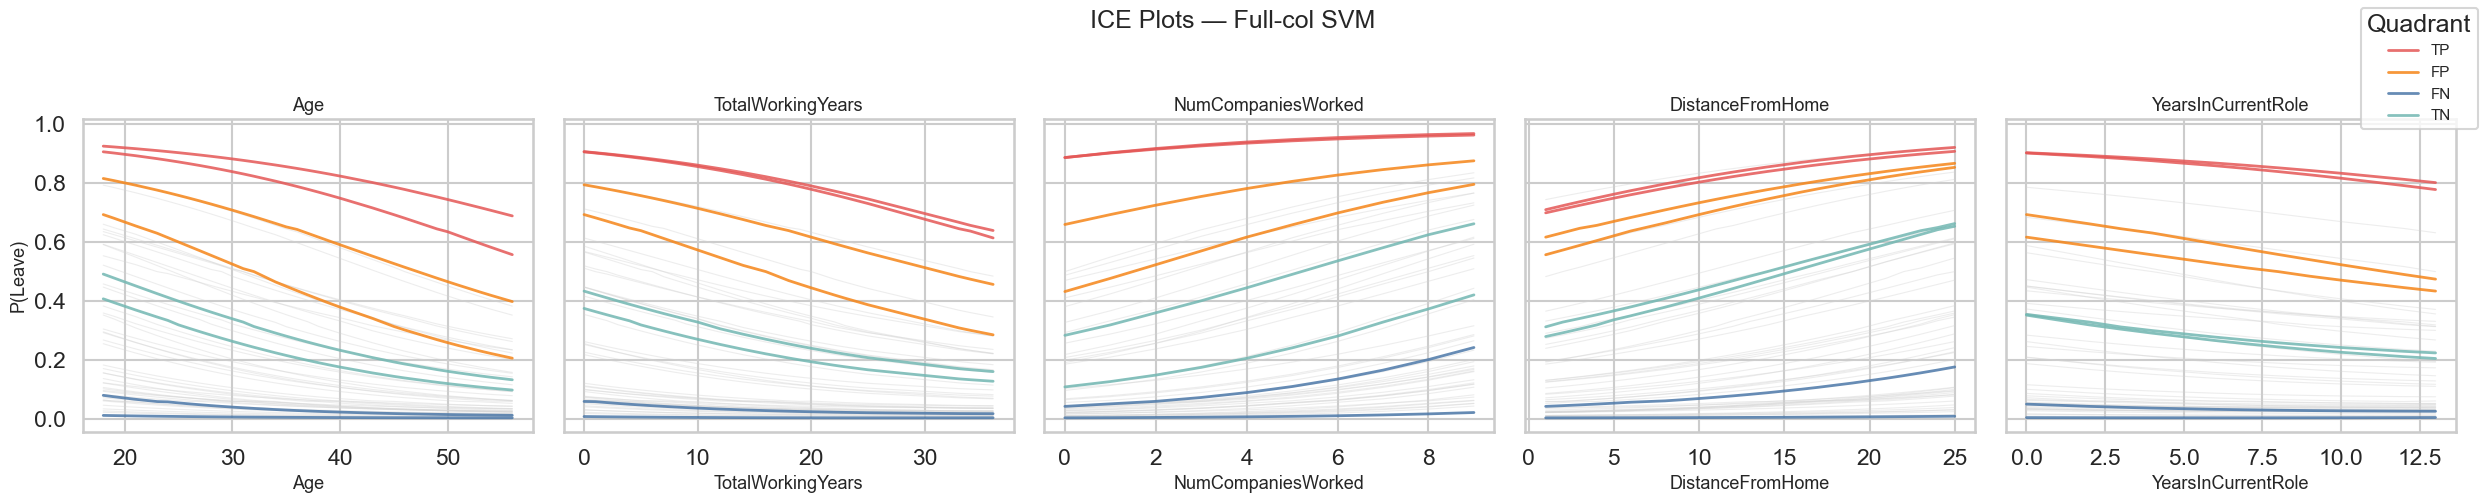

In [10]:
# ── ICE plots: Full-col SVM ──
# We manually compute ICE so we can highlight the 8 selected samples.

from sklearn.inspection import partial_dependence

QUADRANT_COLORS = {"TP": "#E45756", "FP": "#F58518", "FN": "#4C78A8", "TN": "#72B7B2"}
QUADRANT_LABELS = ["TP", "FP", "FN", "TN"]

X_ice_fc = X_test_fc.iloc[ice_sample_idx]

fig, axes = plt.subplots(1, len(ICE_FEATURES), figsize=(5 * len(ICE_FEATURES), 5), sharey=True)
fig.suptitle("ICE Plots — Full-col SVM", fontsize=18, y=1.02)

for ax, feat in zip(axes, ICE_FEATURES):
    feat_idx = list(X_test_fc.columns).index(feat)
    result = partial_dependence(
        svm_fc, X_ice_fc, features=[feat_idx],
        kind="individual", grid_resolution=30,
    )
    ice_values = result["individual"][0]  # shape: (n_samples, n_grid_points)
    grid_values = result["grid_values"][0]

    # Background lines (grey)
    for i in range(ice_values.shape[0]):
        if i not in selected_positions:
            ax.plot(grid_values, ice_values[i], color="lightgrey", alpha=0.4, linewidth=0.8)

    # Highlighted selected samples
    for k, pos in enumerate(selected_positions):
        q = ["TP", "TP", "FP", "FP", "FN", "FN", "TN", "TN"][k]
        ax.plot(grid_values, ice_values[pos], color=QUADRANT_COLORS[q],
                linewidth=2, alpha=0.85, label=q if k % 2 == 0 else None)

    ax.set_xlabel(feat)
    ax.set_ylabel("P(Leave)" if ax == axes[0] else "")
    ax.set_title(feat, fontsize=13)

# Single legend for all subplots
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=11, title="Quadrant")
plt.tight_layout()
plt.show()

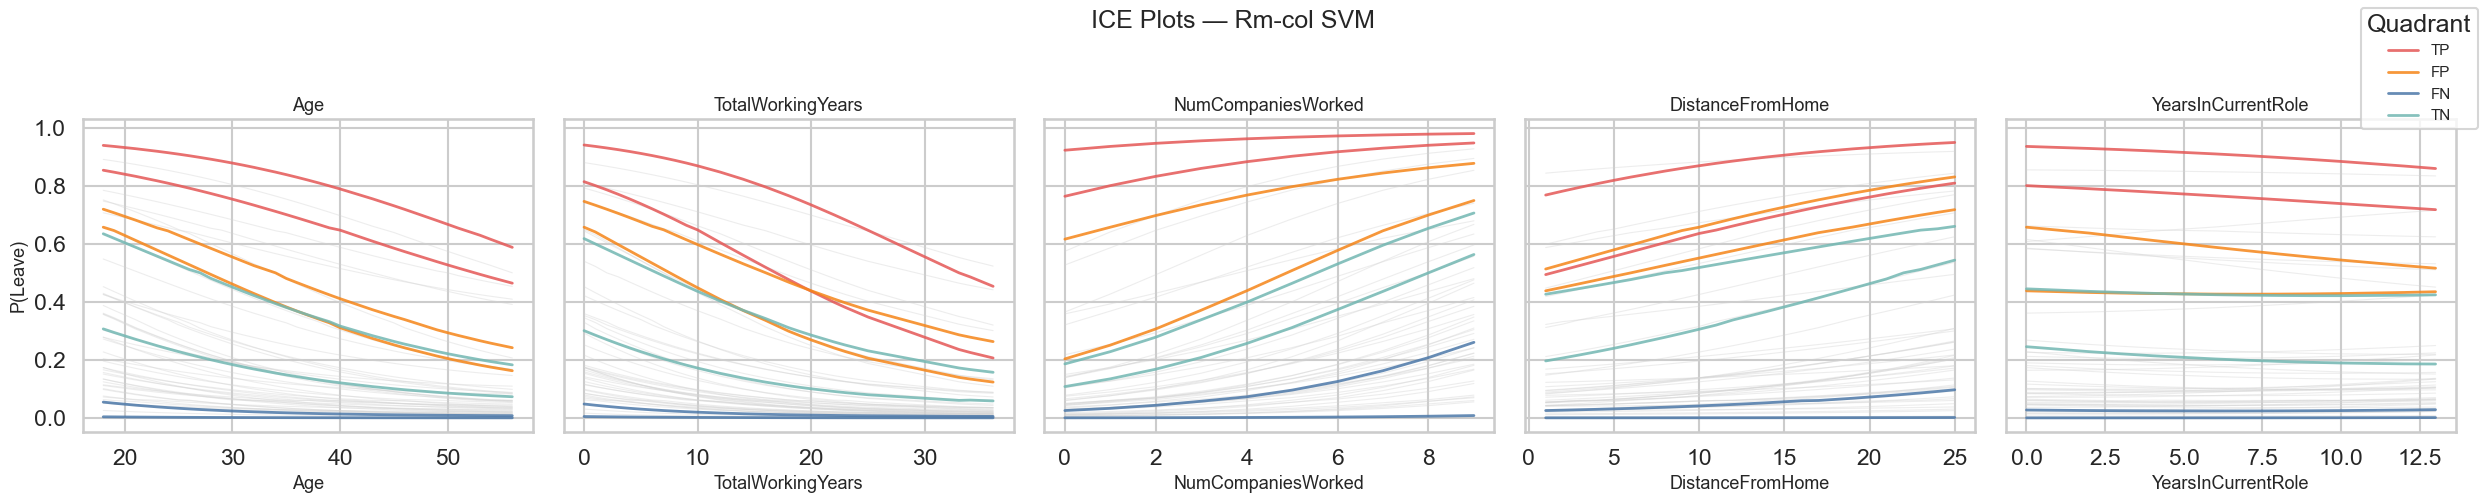

In [11]:
# ── ICE plots: Rm-col SVM ──

X_ice_rm = X_test_rm.iloc[ice_sample_idx]

fig, axes = plt.subplots(1, len(ICE_FEATURES), figsize=(5 * len(ICE_FEATURES), 5), sharey=True)
fig.suptitle("ICE Plots — Rm-col SVM", fontsize=18, y=1.02)

for ax, feat in zip(axes, ICE_FEATURES):
    feat_idx = list(X_test_rm.columns).index(feat)
    result = partial_dependence(
        svm_rm, X_ice_rm, features=[feat_idx],
        kind="individual", grid_resolution=30,
    )
    ice_values = result["individual"][0]
    grid_values = result["grid_values"][0]

    for i in range(ice_values.shape[0]):
        if i not in selected_positions:
            ax.plot(grid_values, ice_values[i], color="lightgrey", alpha=0.4, linewidth=0.8)

    for k, pos in enumerate(selected_positions):
        q = ["TP", "TP", "FP", "FP", "FN", "FN", "TN", "TN"][k]
        ax.plot(grid_values, ice_values[pos], color=QUADRANT_COLORS[q],
                linewidth=2, alpha=0.85, label=q if k % 2 == 0 else None)

    ax.set_xlabel(feat)
    ax.set_ylabel("P(Leave)" if ax == axes[0] else "")
    ax.set_title(feat, fontsize=13)

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=11, title="Quadrant")
plt.tight_layout()
plt.show()

### ICE Observations

**Overall trend (both models):**
- **Age** and **TotalWorkingYears** show the strongest monotonic effect: P(Leave) drops sharply as these features increase. Young, low-tenure employees are universally higher risk.
- **NumCompaniesWorked** shows a mild upward slope — more job-hopping associates with higher predicted attrition.
- **DistanceFromHome** has a moderate positive effect: longer commute → higher risk, especially visible for TP samples.
- **YearsWithCurrManager** shows a downward trend: longer tenure with current manager → lower predicted risk — consistent with a "manager loyalty" effect.

**Cross-model comparison:**
- The **rm-col model** shows steeper ICE curves per feature, confirming that fewer features forces each remaining feature to carry more explanatory weight.
- The **full-col model** distributes influence more evenly, producing smoother but subtler individual effects.

**Per-quadrant patterns:**
- **TP samples (red/orange)** sit at the top of the ICE band — high baseline risk that stays elevated across most feature ranges.
- **FN samples (green)** are near the bottom with nearly flat curves — the model found no single-feature signal strong enough to flag them. This foreshadows the FN blind-spot discussed in Section 5.
- **TN samples (blue)** sit just below the threshold region, confirming they are genuine borderline cases.

## Section 3: SHAP Local Explanations

SHAP (SHapley Additive exPlanations) decomposes each prediction into **additive feature contributions**. For each sample, every feature gets a SHAP value indicating how much it pushed the prediction towards Leave (+) or Stay (−) relative to the average prediction.

Since SVM has no tree structure, we use `KernelExplainer` with a k-means summary of the training set as the background distribution. We compute SHAP values only for the 8 selected samples to keep computation tractable.

In [12]:
# ── Helper: get transformed feature names after ColumnTransformer ──

def get_transformed_feature_names(pipeline, numeric_features, categorical_features):
    """Extract feature names after preprocessing (numeric + OHE categorical)."""
    prep = pipeline.named_steps["prep"]
    ohe = prep.named_transformers_["cat"].named_steps["onehot"]
    cat_names = ohe.get_feature_names_out(categorical_features).tolist()
    return numeric_features + cat_names


def compute_shap_values(model, X_train, X_explain, numeric_features, categorical_features, n_background=50):
    """Compute SHAP values for X_explain using KernelExplainer on transformed data."""
    prep = model.named_steps["prep"]
    clf  = model.named_steps["model"]

    # Transform data
    X_train_t   = prep.transform(X_train)
    X_explain_t = prep.transform(X_explain)
    feat_names  = get_transformed_feature_names(model, numeric_features, categorical_features)

    # k-means background summary for KernelExplainer
    background = shap.kmeans(X_train_t, n_background)

    explainer = shap.KernelExplainer(clf.predict_proba, background)
    shap_values = explainer.shap_values(X_explain_t, nsamples=200)

    # KernelExplainer may return either:
    # - list [class0, class1] with arrays (n_samples, n_features), or
    # - ndarray (n_samples, n_features, n_classes) for binary predict_proba
    # We need class 1 = Leave (positive).
    if isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        sv = np.asarray(shap_values)
        if sv.ndim == 3:
            sv = sv[:, :, 1]

    return sv, feat_names, explainer.expected_value


# ── Compute for both models ──
X_selected_fc = X_test_fc.loc[all_selected]
X_selected_rm = X_test_rm.loc[all_selected]

print("Computing SHAP values for full-col SVM (this may take a few minutes)...")
shap_values_fc, feat_names_fc, base_value_fc = compute_shap_values(
    svm_fc, X_train_fc, X_selected_fc, num_features_fc, cat_features_fc
)

print("Computing SHAP values for rm-col SVM...")
shap_values_rm, feat_names_rm, base_value_rm = compute_shap_values(
    svm_rm, X_train_rm, X_selected_rm, num_features_rm, cat_features_rm
)

print(f"\nFull-col SHAP shape: {shap_values_fc.shape}  (features: {len(feat_names_fc)})")
print(f"Rm-col   SHAP shape: {shap_values_rm.shape}  (features: {len(feat_names_rm)})")

Computing SHAP values for full-col SVM (this may take a few minutes)...


100%|██████████| 8/8 [00:02<00:00,  3.20it/s]


Computing SHAP values for rm-col SVM...


100%|██████████| 8/8 [00:02<00:00,  3.88it/s]


Full-col SHAP shape: (8, 55)  (features: 55)
Rm-col   SHAP shape: (8, 43)  (features: 43)


In [13]:
# ── Aggregate OHE SHAP values back to original feature level ──
# For categorical features encoded as multiple OHE columns, sum their SHAP values
# back to the original feature name for interpretability.

def aggregate_shap_to_original(shap_vals, feat_names, original_features):
    """Sum OHE SHAP values back to original categorical feature names."""
    agg = {}
    for orig_feat in original_features:
        # Find all transformed columns that belong to this original feature
        mask = [i for i, fn in enumerate(feat_names) if fn == orig_feat or fn.startswith(orig_feat + "_")]
        if mask:
            agg[orig_feat] = shap_vals[:, mask].sum(axis=1)
    agg_names = list(agg.keys())
    agg_values = np.column_stack(list(agg.values()))
    return agg_values, agg_names


all_features_fc = num_features_fc + cat_features_fc
all_features_rm = num_features_rm + cat_features_rm

shap_agg_fc, agg_names_fc = aggregate_shap_to_original(shap_values_fc, feat_names_fc, all_features_fc)
shap_agg_rm, agg_names_rm = aggregate_shap_to_original(shap_values_rm, feat_names_rm, all_features_rm)

print(f"Aggregated full-col: {shap_agg_fc.shape} → {len(agg_names_fc)} original features")
print(f"Aggregated rm-col:   {shap_agg_rm.shape} → {len(agg_names_rm)} original features")

Aggregated full-col: (8, 34) → 34 original features
Aggregated rm-col:   (8, 22) → 22 original features


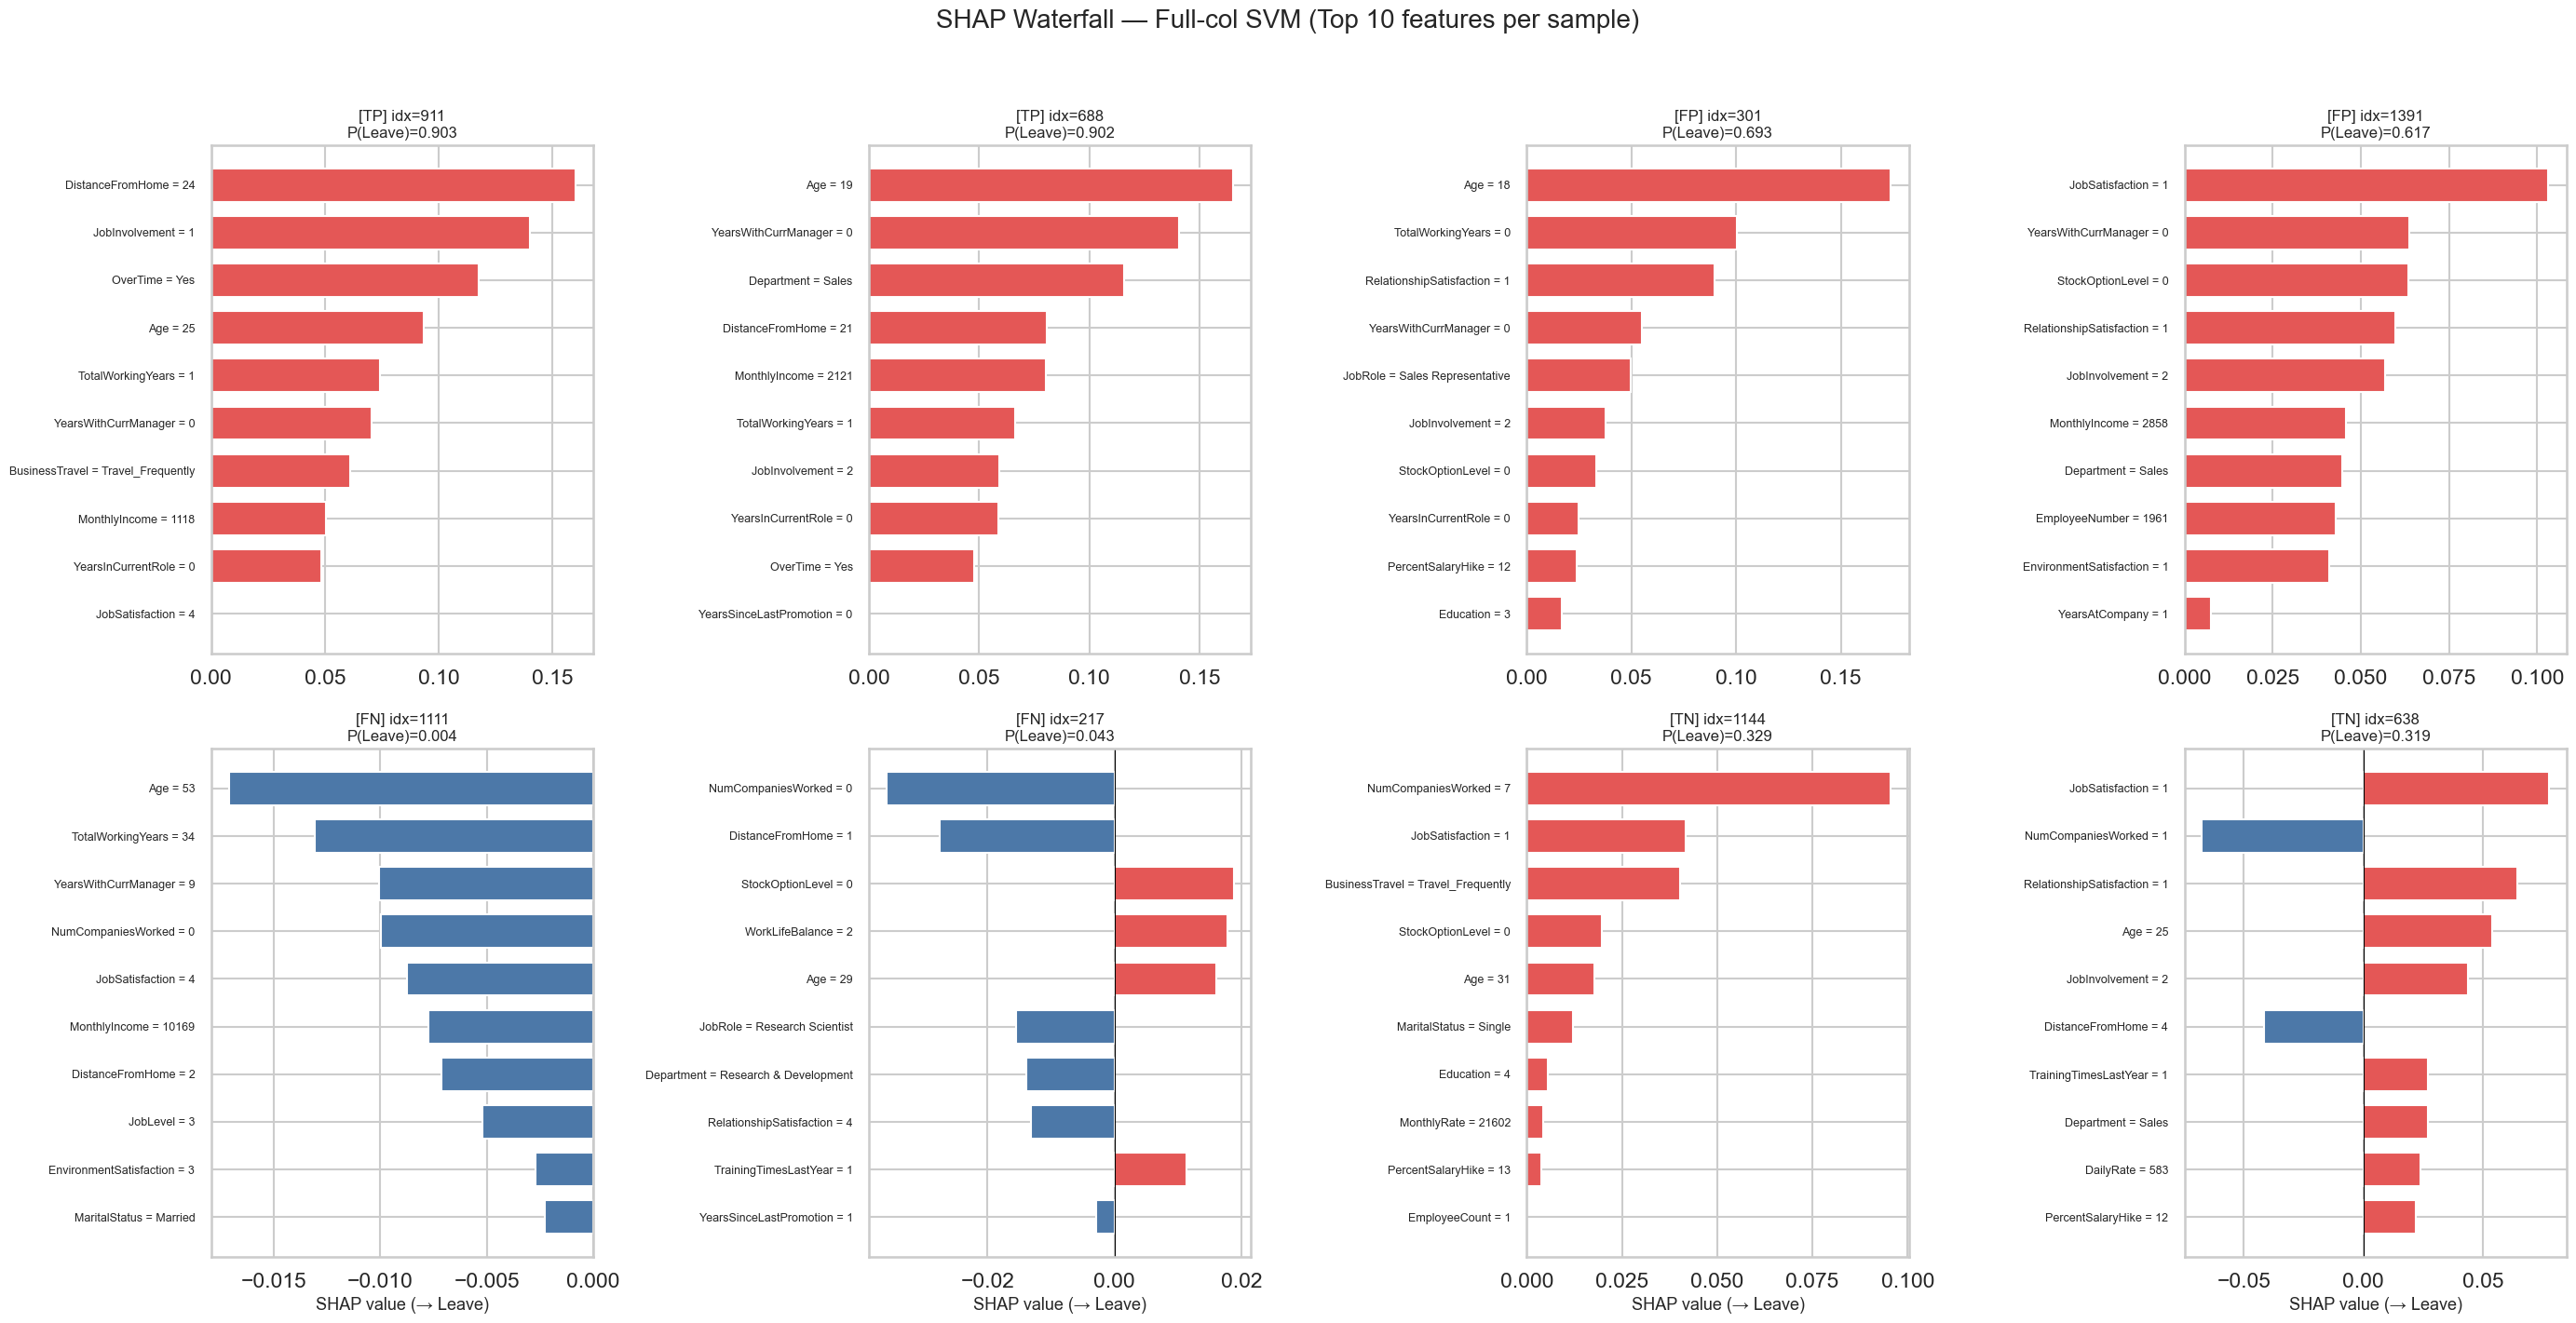

In [14]:
# ── SHAP Waterfall Plots: Full-col SVM (8 samples, 2 per quadrant) ──

base_val = base_value_fc[1] if isinstance(base_value_fc, (list, np.ndarray)) else base_value_fc

fig, axes = plt.subplots(2, 4, figsize=(28, 14))
fig.suptitle("SHAP Waterfall — Full-col SVM (Top 10 features per sample)", fontsize=20, y=1.02)

quadrant_order = ["TP", "TP", "FP", "FP", "FN", "FN", "TN", "TN"]

for k, (idx, ax) in enumerate(zip(all_selected, axes.flatten())):
    q = quadrant_order[k]
    sv = shap_agg_fc[k]
    feat_vals = X_selected_fc.loc[idx]

    # Top 10 by absolute SHAP value
    top_idx = np.argsort(np.abs(sv))[-10:]
    top_names = [agg_names_fc[i] for i in top_idx]
    top_sv    = sv[top_idx]
    top_fv    = [feat_vals[n] if n in feat_vals.index else "?" for n in top_names]

    colors = ["#E45756" if v > 0 else "#4C78A8" for v in top_sv]
    y_pos = range(len(top_names))
    labels = [f"{n} = {fv}" for n, fv in zip(top_names, top_fv)]

    ax.barh(y_pos, top_sv, color=colors, edgecolor="white", height=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.axvline(0, color="black", linewidth=0.8)
    proba_val = proba_fc[X_test_fc.index.get_loc(idx)]
    ax.set_title(f"[{q}] idx={idx}\nP(Leave)={proba_val:.3f}", fontsize=12)
    ax.set_xlabel("SHAP value (→ Leave)" if k >= 4 else "")

plt.tight_layout()
plt.show()

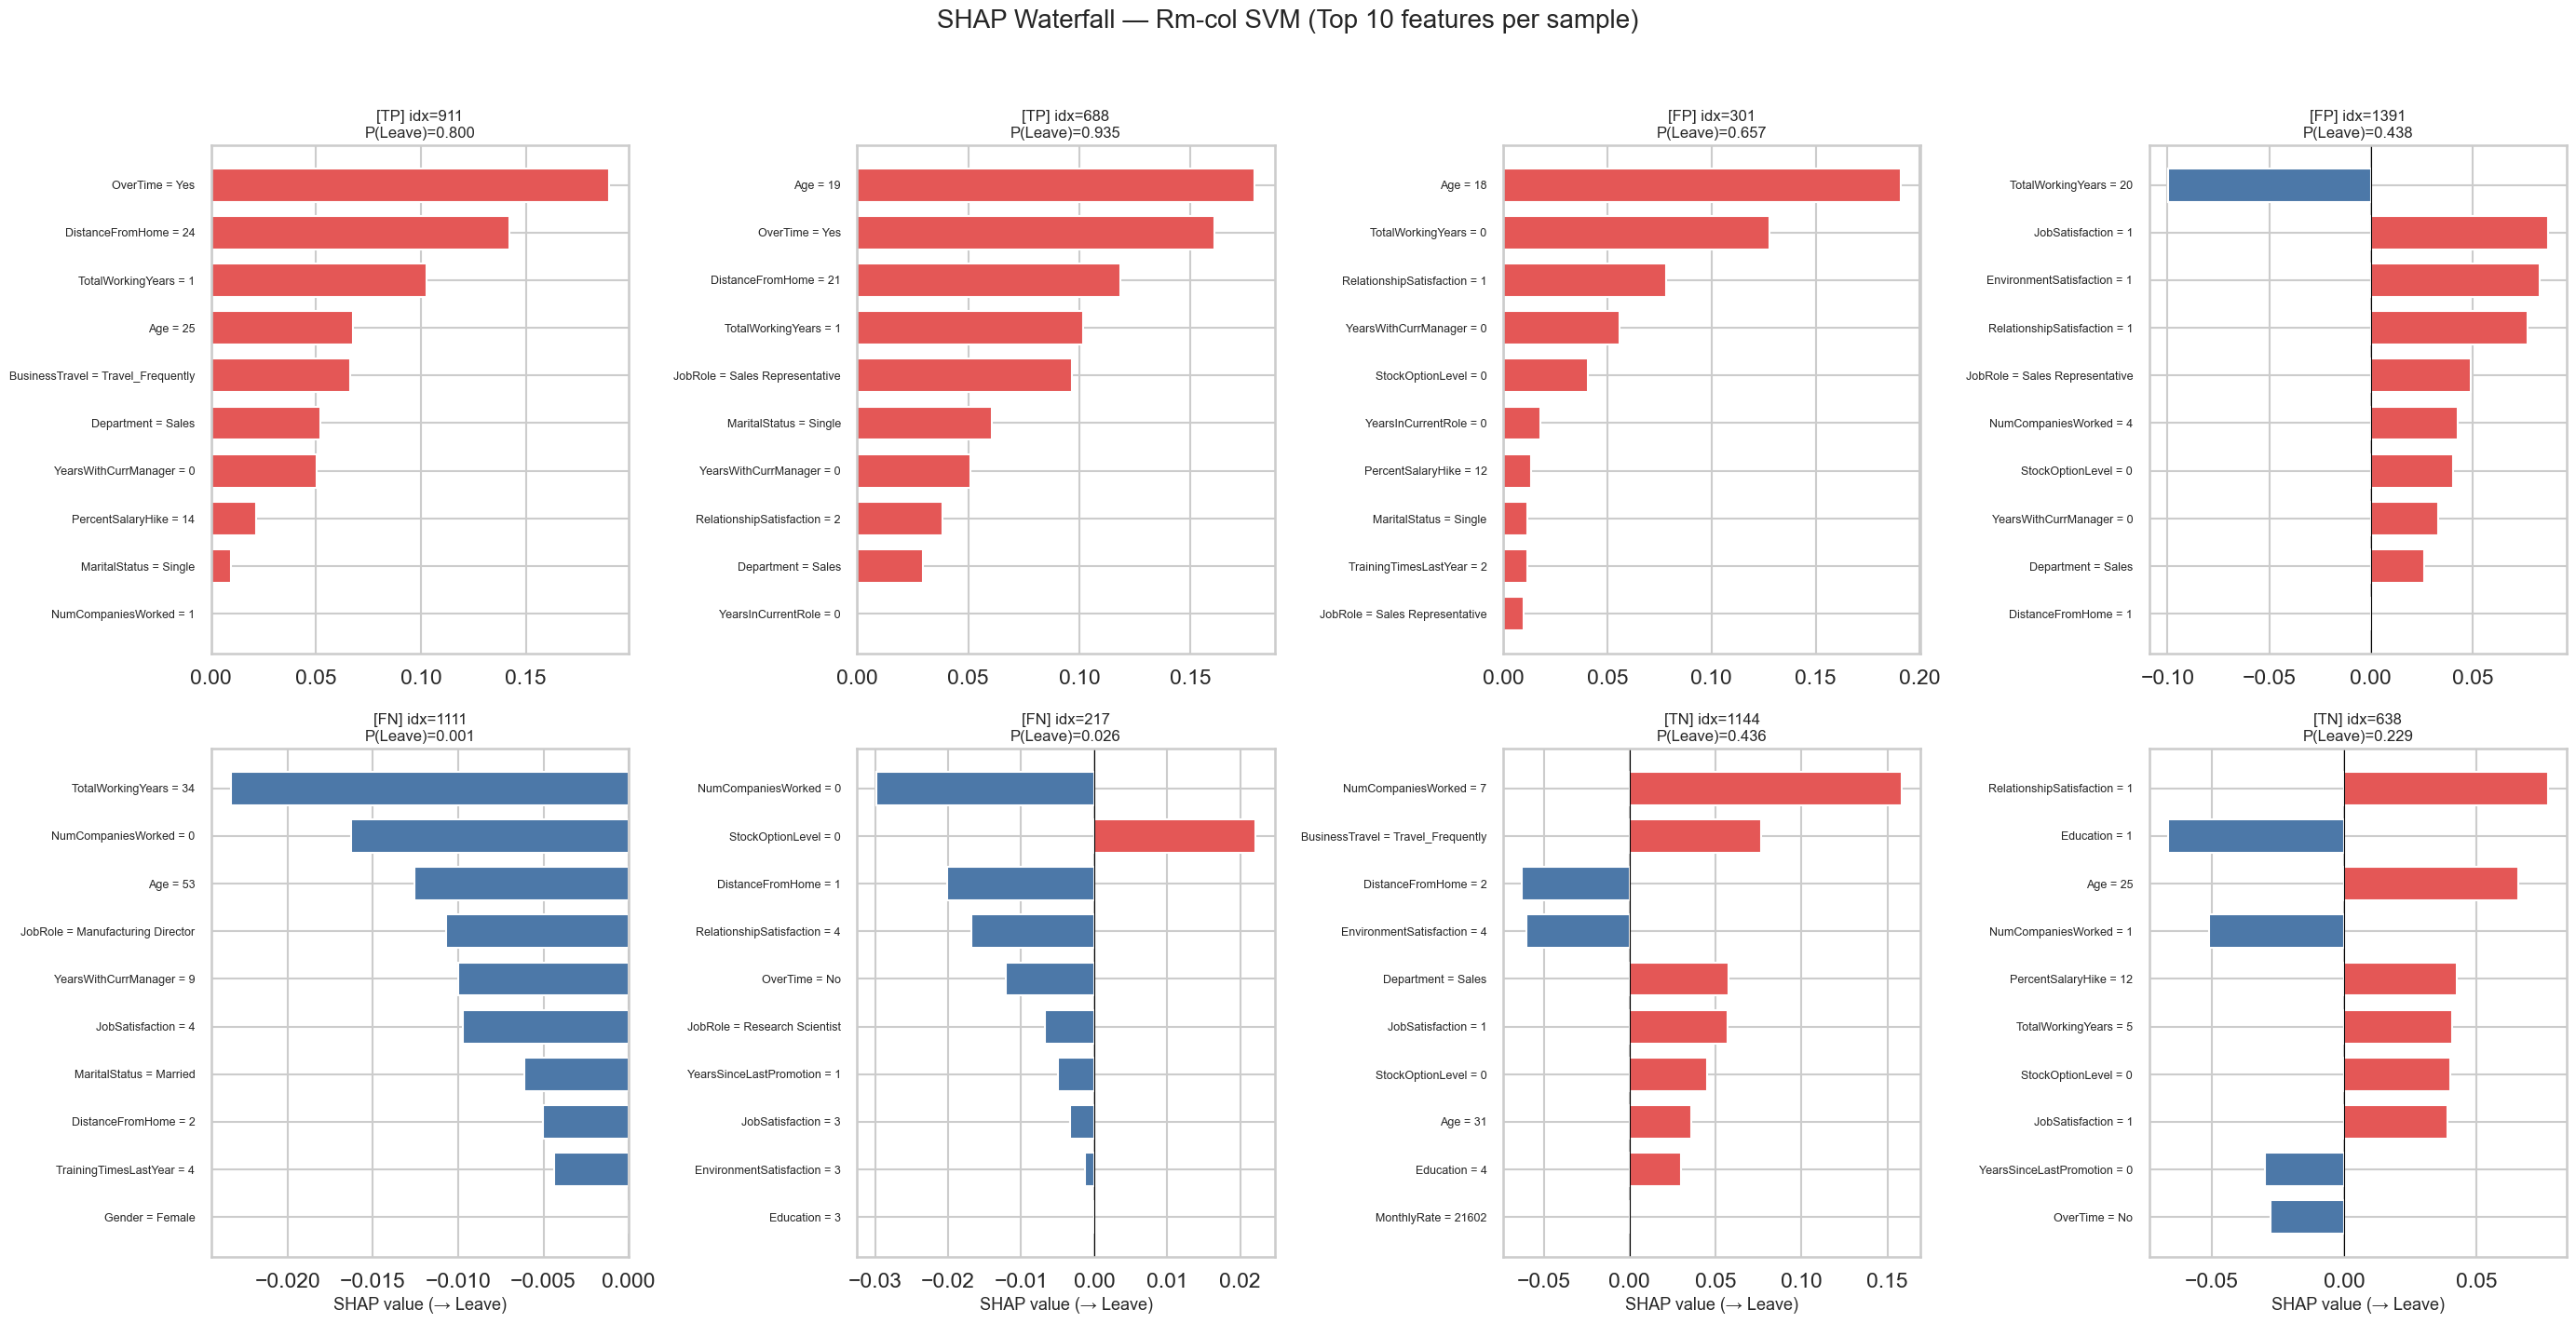

In [15]:
# ── SHAP Waterfall Plots: Rm-col SVM ──

base_val_rm = base_value_rm[1] if isinstance(base_value_rm, (list, np.ndarray)) else base_value_rm

fig, axes = plt.subplots(2, 4, figsize=(28, 14))
fig.suptitle("SHAP Waterfall — Rm-col SVM (Top 10 features per sample)", fontsize=20, y=1.02)

for k, (idx, ax) in enumerate(zip(all_selected, axes.flatten())):
    q = quadrant_order[k]
    sv = shap_agg_rm[k]
    feat_vals = X_selected_rm.loc[idx]

    top_idx = np.argsort(np.abs(sv))[-10:]
    top_names = [agg_names_rm[i] for i in top_idx]
    top_sv    = sv[top_idx]
    top_fv    = [feat_vals[n] if n in feat_vals.index else "?" for n in top_names]

    colors = ["#E45756" if v > 0 else "#4C78A8" for v in top_sv]
    y_pos = range(len(top_names))
    labels = [f"{n} = {fv}" for n, fv in zip(top_names, top_fv)]

    ax.barh(y_pos, top_sv, color=colors, edgecolor="white", height=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.axvline(0, color="black", linewidth=0.8)
    proba_val = proba_rm[X_test_rm.index.get_loc(idx)]
    ax.set_title(f"[{q}] idx={idx}\nP(Leave)={proba_val:.3f}", fontsize=12)
    ax.set_xlabel("SHAP value (→ Leave)" if k >= 4 else "")

plt.tight_layout()
plt.show()


[TP] Employee idx=911 — Full-col SVM  P(Leave)=0.903


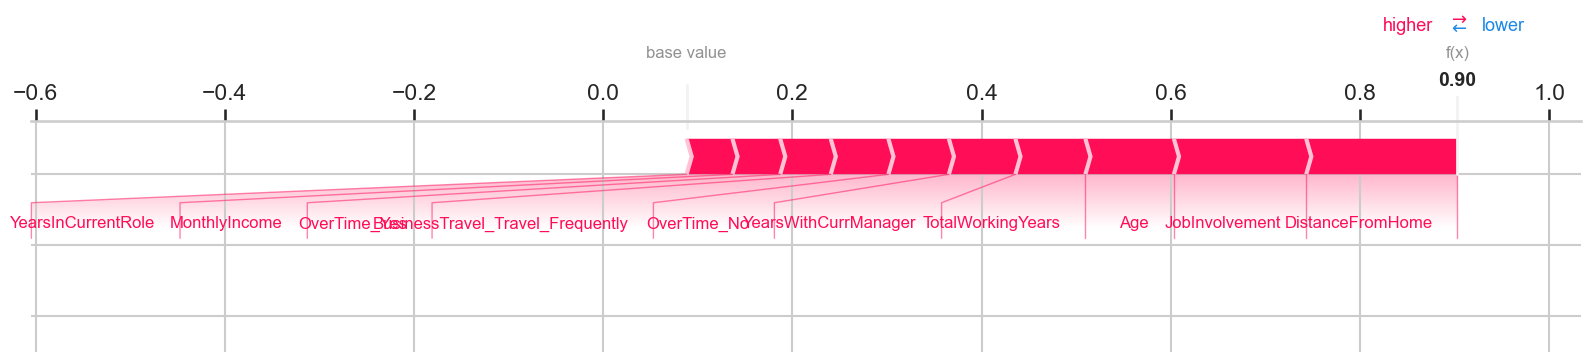

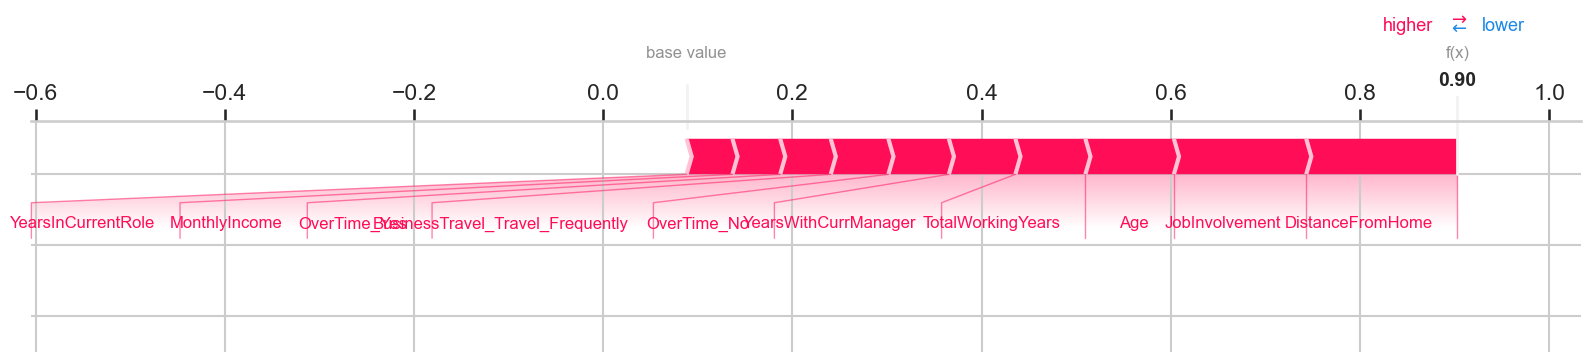


[TP] Employee idx=688 — Full-col SVM  P(Leave)=0.902


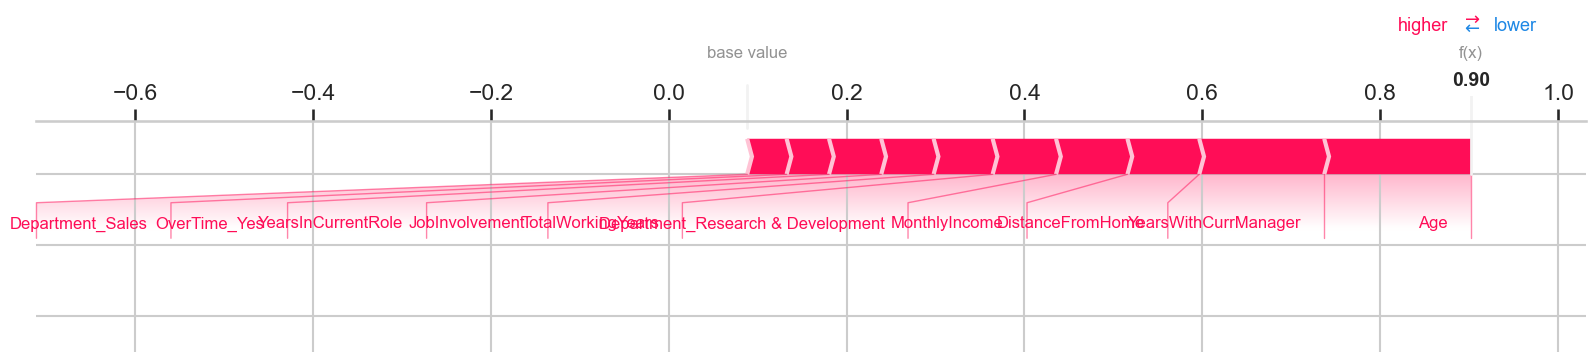

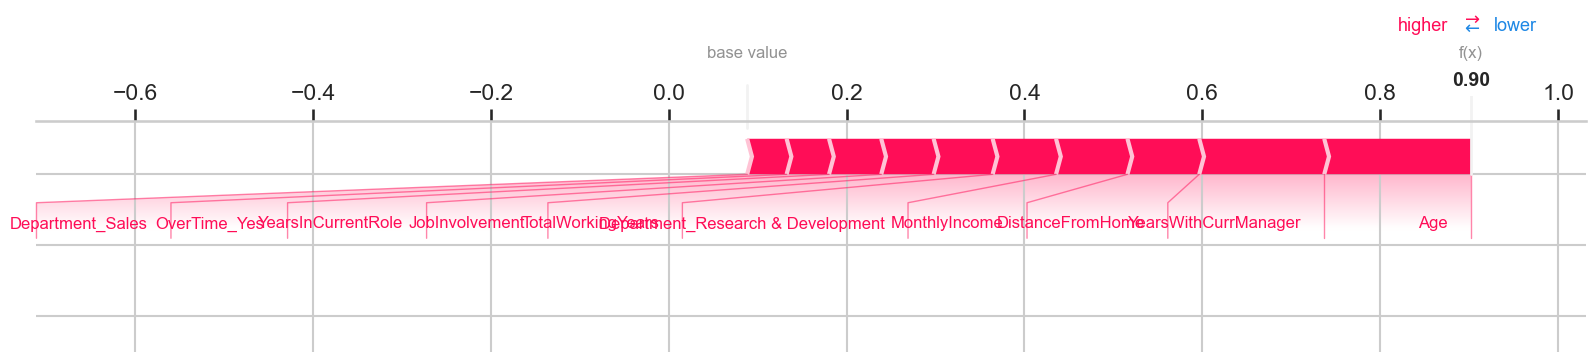


[FP] Employee idx=301 — Full-col SVM  P(Leave)=0.693


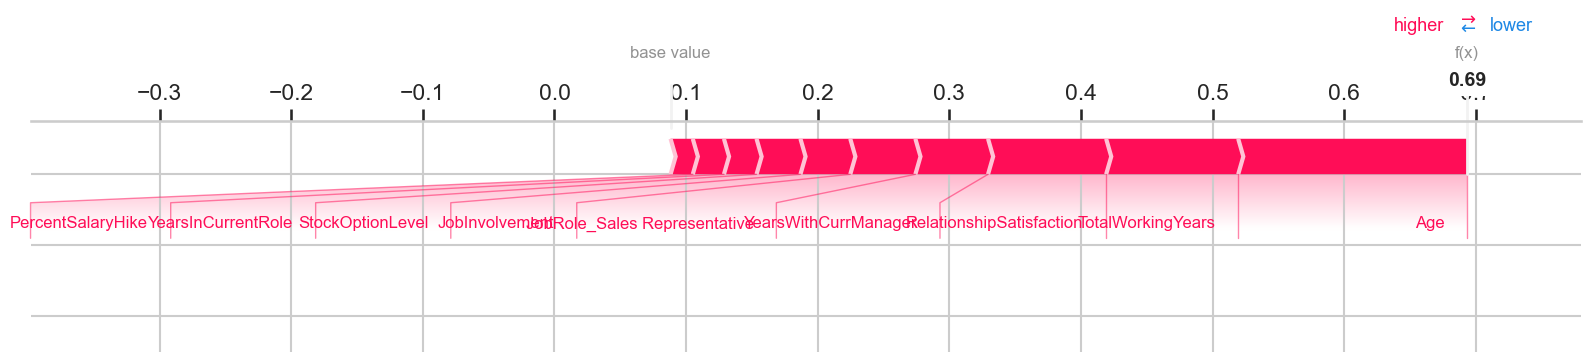

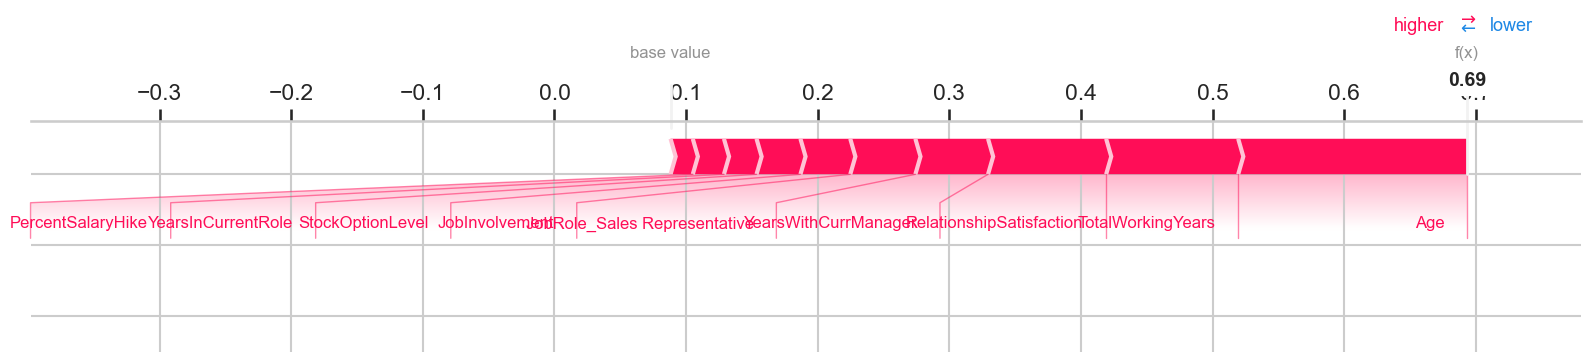


[FP] Employee idx=1391 — Full-col SVM  P(Leave)=0.617


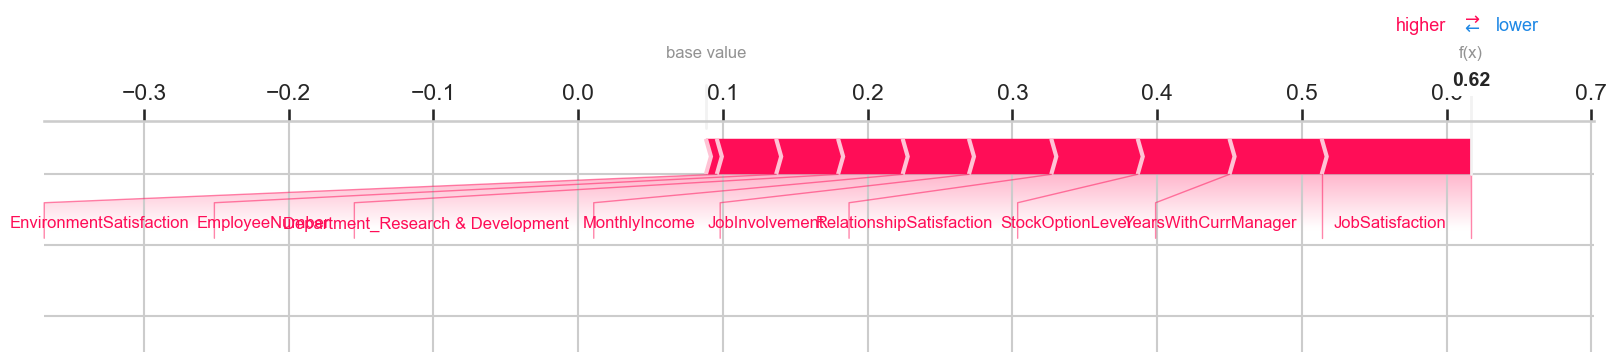

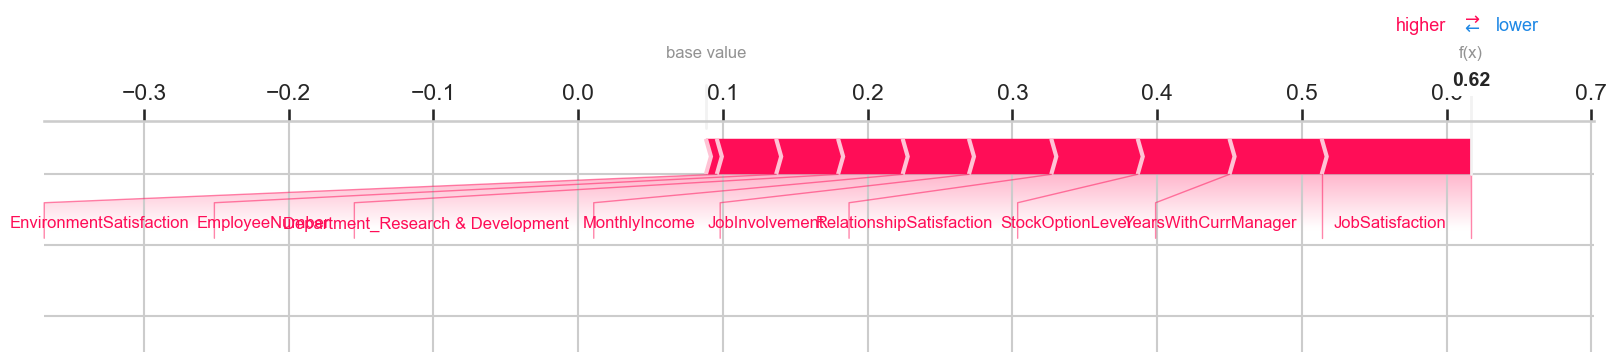


[FN] Employee idx=1111 — Full-col SVM  P(Leave)=0.004


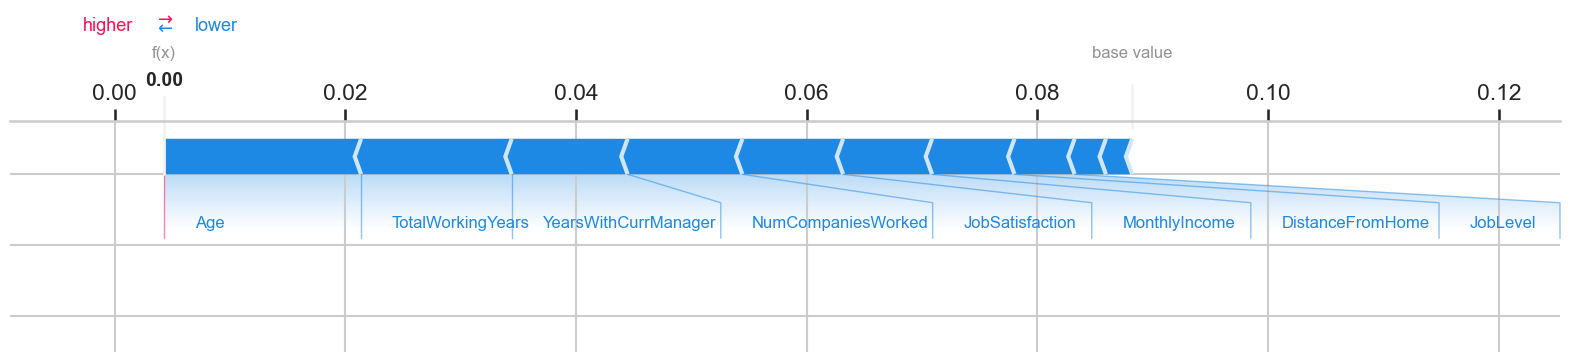

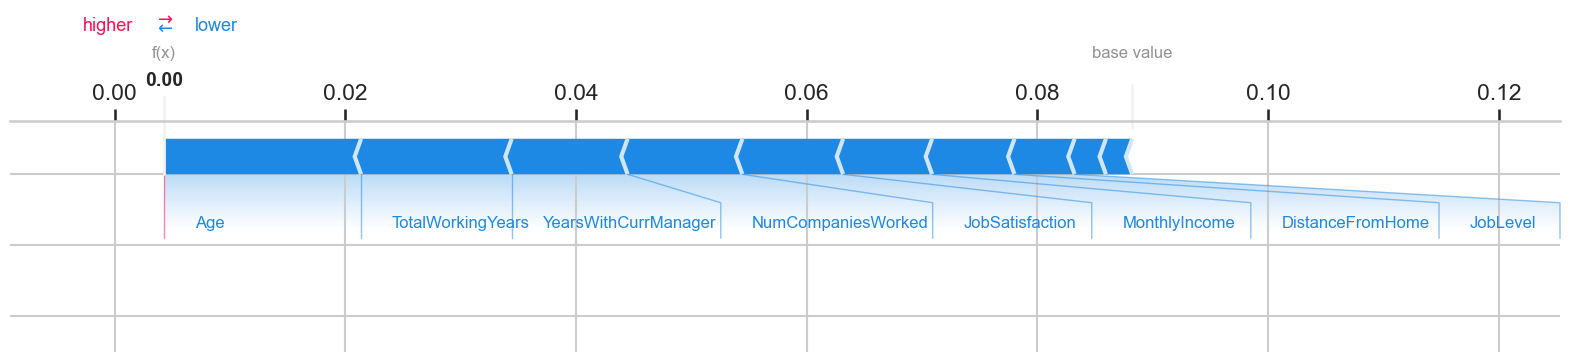


[FN] Employee idx=217 — Full-col SVM  P(Leave)=0.043


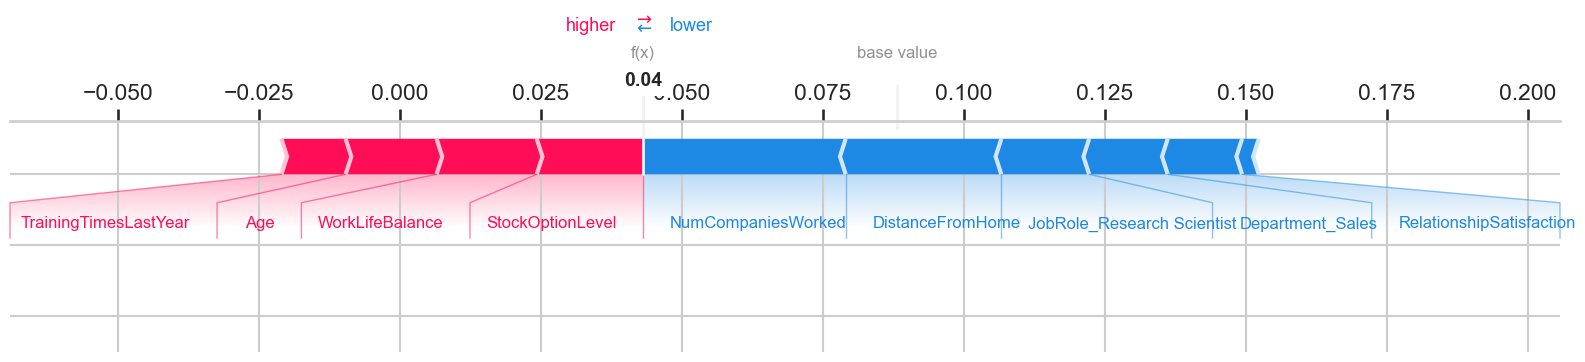

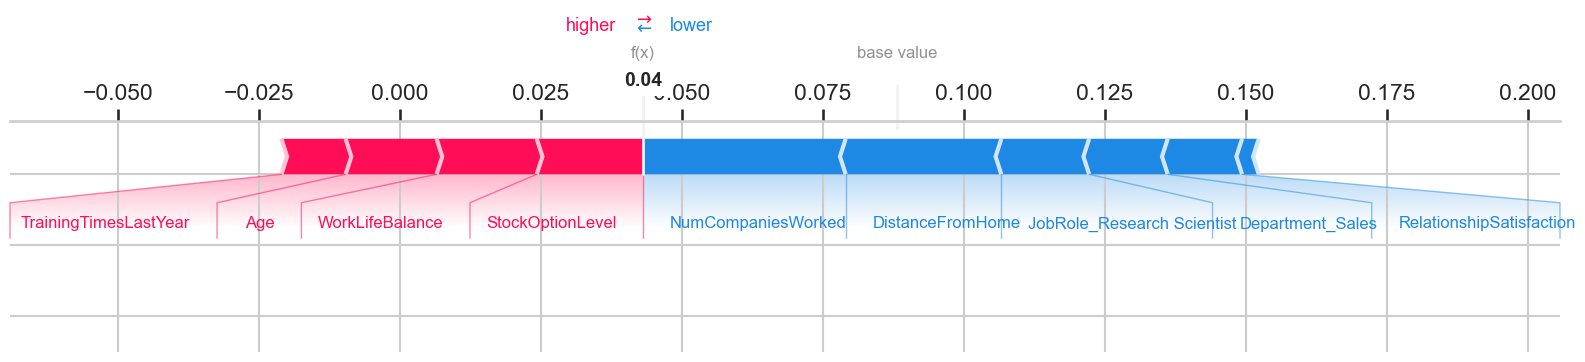


[TN] Employee idx=1144 — Full-col SVM  P(Leave)=0.329


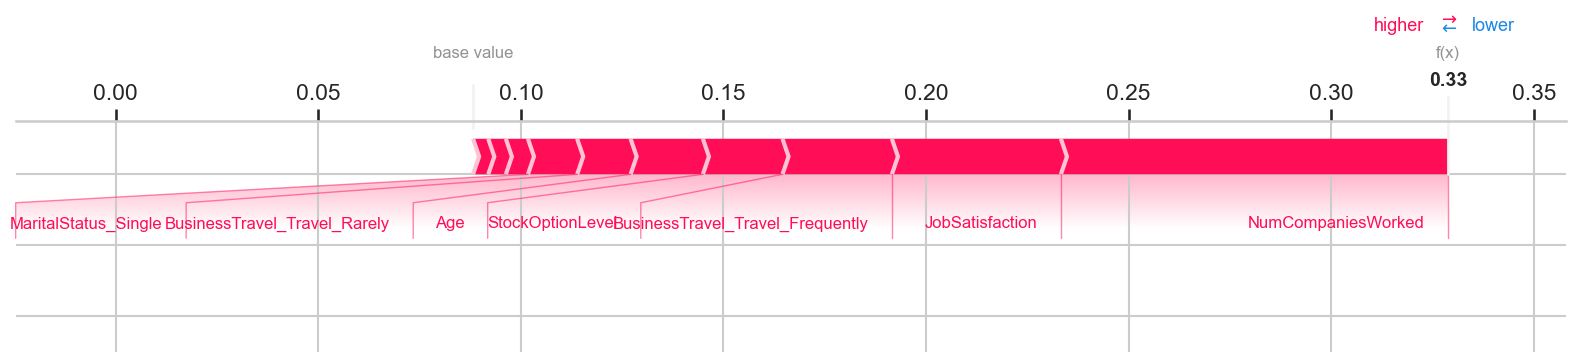

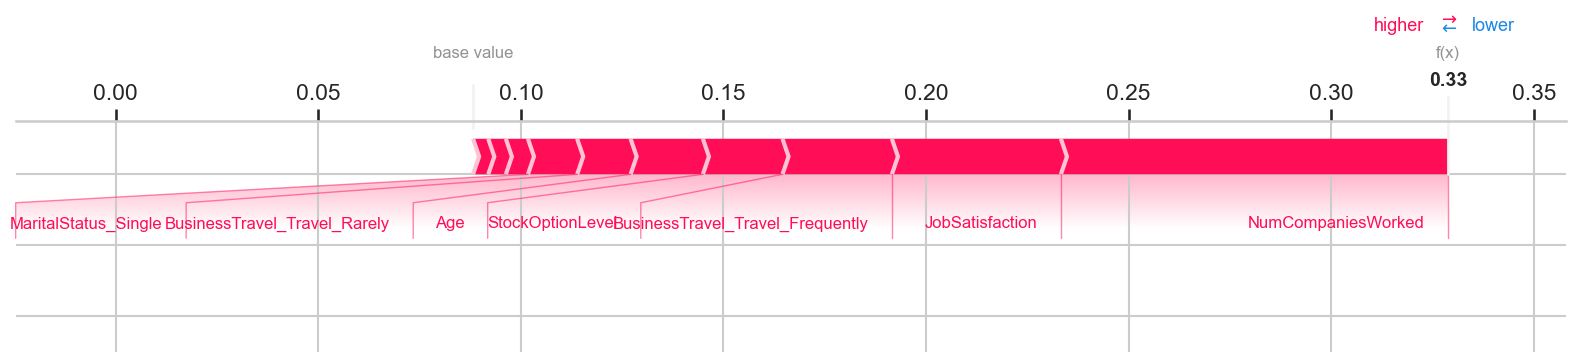


[TN] Employee idx=638 — Full-col SVM  P(Leave)=0.319


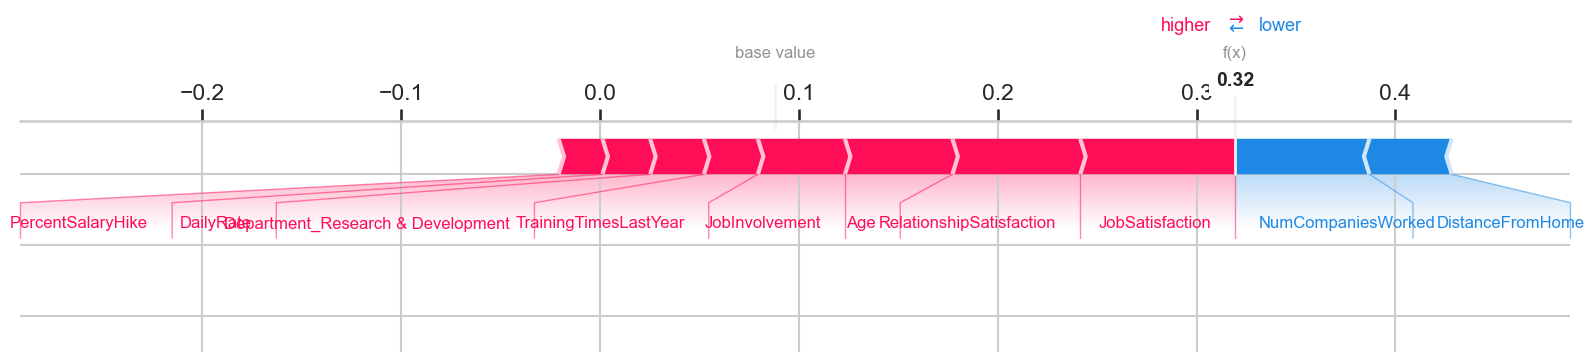

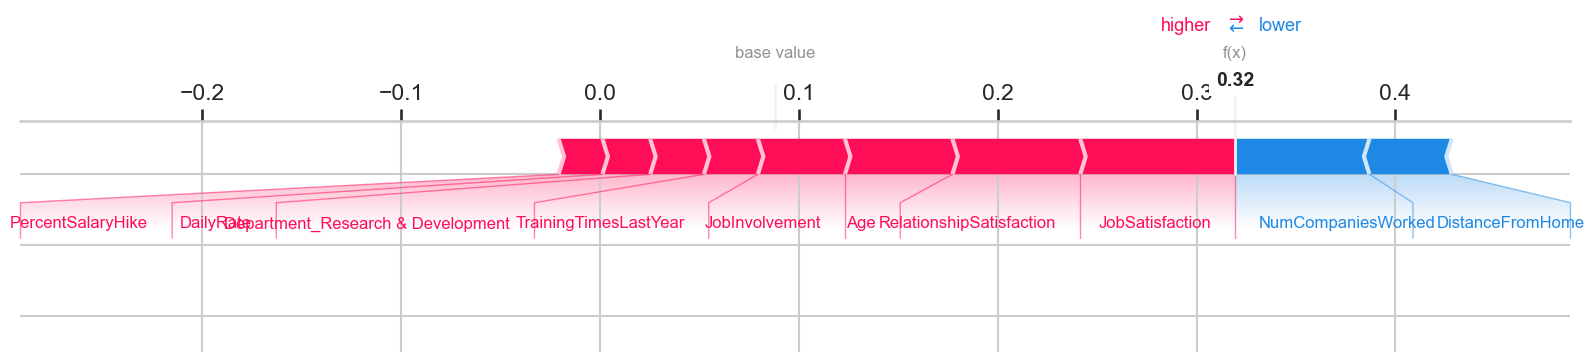

In [16]:
# ── SHAP Force Plots (interactive HTML) ──
# These provide a compact, color-coded visualization of feature contributions.

shap.initjs()

# Full-col: show force plots for each selected sample
prep_fc = svm_fc.named_steps["prep"]
X_explain_t_fc = prep_fc.transform(X_selected_fc)

base_val_fc_scalar = base_value_fc[1] if isinstance(base_value_fc, (list, np.ndarray)) else base_value_fc

for k, idx in enumerate(all_selected):
    q = quadrant_order[k]
    print(f"\n[{q}] Employee idx={idx} — Full-col SVM  P(Leave)={proba_fc[X_test_fc.index.get_loc(idx)]:.3f}")
    display(shap.force_plot(
        base_val_fc_scalar,
        shap_values_fc[k],
        feature_names=feat_names_fc,
        matplotlib=True,
        show=False,
    ))
    plt.show()

## Section 4: Anchors (Rule-based Local Explanations)

Anchors generate **if-then rules** that are sufficient to guarantee a prediction with high precision. Each anchor states: *"As long as these conditions hold, the model predicts class X with ≥ P% confidence."*

Key properties:
- **Precision**: How often the rule gives the correct prediction (higher = more reliable)
- **Coverage**: What fraction of the dataset the rule applies to (higher = more general)

Anchors are more stable than LIME because they identify a *region* rather than fitting a local linear model.

In [17]:
# ── Anchors setup ──
# AnchorTabular requires raw data (not OHE). Alibi indexes categories as 0..K-1 in val2idx;
# raw strings in fit/explain break cat_lookup vs val2idx (KeyError). Encode categoricals as
# floats in [0, K-1], then decode to strings inside predict_fn for the sklearn pipeline.

def dataframe_to_anchor_array(X_df, feature_names, cat_dict):
    """Encode categoricals as float codes matching categorical_names order."""
    arr = np.zeros((len(X_df), len(feature_names)), dtype=np.float64)
    for j, fn in enumerate(feature_names):
        if j in cat_dict:
            labs = cat_dict[j]
            mapping = {s: float(i) for i, s in enumerate(labs)}
            arr[:, j] = X_df[fn].astype(str).map(mapping)
        else:
            arr[:, j] = X_df[fn].astype(float)
    return arr


def get_categorical_names_dict(cat_features, feature_names, X_train, *extra_frames):
    """Union of category strings across train (+ val/test) so test-only levels are included."""
    cat_dict = {}
    for col in cat_features:
        idx = feature_names.index(col)
        u = set(X_train[col].astype(str).unique())
        for df in extra_frames:
            u.update(df[col].astype(str).unique())
        cat_dict[idx] = sorted(u)
    return cat_dict


def setup_anchor_explainer(model, X_train_np, feature_names, categorical_names_dict):
    def predict_fn(x):
        x = np.atleast_2d(x)
        df = pd.DataFrame(x, columns=feature_names)
        for j in range(len(feature_names)):
            if j in categorical_names_dict:
                labs = categorical_names_dict[j]
                codes = np.rint(df.iloc[:, j].astype(float)).astype(int)
                df.iloc[:, j] = [labs[c] if 0 <= c < len(labs) else labs[0] for c in codes]
            else:
                df.iloc[:, j] = df.iloc[:, j].astype(float)
        return model.predict(df)

    explainer = AnchorTabular(
        predictor=predict_fn,
        feature_names=feature_names,
        categorical_names=categorical_names_dict,
    )
    explainer.fit(X_train_np)
    return explainer


_fn_fc = list(X_train_fc.columns)
cat_names_dict_fc = get_categorical_names_dict(
    cat_features_fc, _fn_fc, X_train_fc, X_val_fc, X_test_fc
)
X_train_anchor_fc = dataframe_to_anchor_array(X_train_fc, _fn_fc, cat_names_dict_fc)

print("Setting up full-col Anchor explainer...")
anchor_fc = setup_anchor_explainer(
    svm_fc, X_train_anchor_fc, _fn_fc, cat_names_dict_fc
)

_fn_rm = list(X_train_rm.columns)
cat_names_dict_rm = get_categorical_names_dict(
    cat_features_rm, _fn_rm, X_train_rm, X_val_rm, X_test_rm
)
X_train_anchor_rm = dataframe_to_anchor_array(X_train_rm, _fn_rm, cat_names_dict_rm)

print("Setting up rm-col Anchor explainer...")
anchor_rm = setup_anchor_explainer(
    svm_rm, X_train_anchor_rm, _fn_rm, cat_names_dict_rm
)

print("Done.")

Setting up full-col Anchor explainer...
Setting up rm-col Anchor explainer...
Done.


In [18]:
# ── Generate Anchor explanations for all 8 selected samples ──

anchor_results = []

for k, idx in enumerate(all_selected):
    q = quadrant_order[k]
    sample_fc = dataframe_to_anchor_array(X_test_fc.loc[[idx]], _fn_fc, cat_names_dict_fc)[0]
    sample_rm = dataframe_to_anchor_array(X_test_rm.loc[[idx]], _fn_rm, cat_names_dict_rm)[0]

    # Full-col anchor
    exp_fc = anchor_fc.explain(sample_fc, threshold=0.90)
    # Rm-col anchor
    exp_rm = anchor_rm.explain(sample_rm, threshold=0.90)

    anchor_results.append({
        "idx": idx,
        "quadrant": q,
        "actual": "Leave" if y_test_fc.loc[idx] == 1 else "Stay",
        "pred_fc": "Leave" if pred_fc[X_test_fc.index.get_loc(idx)] else "Stay",
        "pred_rm": "Leave" if pred_rm[X_test_rm.index.get_loc(idx)] else "Stay",
        "anchor_fc": " AND ".join(exp_fc.data["anchor"]) if exp_fc.data["anchor"] else "(empty anchor)",
        "precision_fc": f"{exp_fc.data['precision']:.2f}",
        "coverage_fc": f"{exp_fc.data['coverage']:.3f}",
        "anchor_rm": " AND ".join(exp_rm.data["anchor"]) if exp_rm.data["anchor"] else "(empty anchor)",
        "precision_rm": f"{exp_rm.data['precision']:.2f}",
        "coverage_rm": f"{exp_rm.data['coverage']:.3f}",
    })
    print(f"[{q}] idx={idx} done")

print("\nAll anchors computed.")

[TP] idx=911 done
[TP] idx=688 done
[FP] idx=301 done
[FP] idx=1391 done
[FN] idx=1111 done
[FN] idx=217 done
[TN] idx=1144 done
[TN] idx=638 done

All anchors computed.


In [19]:
# ── Display Anchor results as a formatted table ──

anchor_df = pd.DataFrame(anchor_results)

print("=" * 120)
print("ANCHOR EXPLANATIONS — Full-col vs Rm-col SVM")
print("=" * 120)

for _, row in anchor_df.iterrows():
    print(f"\n{'─' * 100}")
    print(f"[{row['quadrant']}] Employee idx={row['idx']}  |  Actual: {row['actual']}")
    print(f"  Full-col pred: {row['pred_fc']}  |  Rm-col pred: {row['pred_rm']}")
    print(f"\n  Full-col Anchor:  IF {row['anchor_fc']}")
    print(f"    → Precision: {row['precision_fc']}  |  Coverage: {row['coverage_fc']}")
    print(f"\n  Rm-col Anchor:    IF {row['anchor_rm']}")
    print(f"    → Precision: {row['precision_rm']}  |  Coverage: {row['coverage_rm']}")

print(f"\n{'─' * 100}")

ANCHOR EXPLANATIONS — Full-col vs Rm-col SVM

────────────────────────────────────────────────────────────────────────────────────────────────────
[TP] Employee idx=911  |  Actual: Leave
  Full-col pred: Leave  |  Rm-col pred: Leave

  Full-col Anchor:  IF DistanceFromHome > 14.00 AND JobRole = Sales Representative AND MaritalStatus = Single
    → Precision: 1.00  |  Coverage: 0.246

  Rm-col Anchor:    IF OverTime = Yes AND JobRole = Sales Representative AND TotalWorkingYears <= 6.00 AND MaritalStatus = Single
    → Precision: 0.94  |  Coverage: 0.049

────────────────────────────────────────────────────────────────────────────────────────────────────
[TP] Employee idx=688  |  Actual: Leave
  Full-col pred: Leave  |  Rm-col pred: Leave

  Full-col Anchor:  IF OverTime = Yes AND JobRole = Sales Representative AND Age <= 30.00
    → Precision: 1.00  |  Coverage: 0.262

  Rm-col Anchor:    IF OverTime = Yes AND JobRole = Sales Representative AND PercentSalaryHike <= 14.00
    → Precision

### Anchor Observations

**TP anchors — simple and high-precision:**
- Employee 911 (full-col): `DistanceFromHome > 14 AND JobRole = Sales Rep AND MaritalStatus = Single` → Precision 1.00, Coverage 24.6%. Only 3 conditions needed.
- Employee 688 (full-col): `OverTime = Yes AND JobRole = Sales Rep AND Age ≤ 30` → Precision 1.00, Coverage 26.2%.
- These confirm that the model's confident predictions rest on a small, interpretable set of risk factors.

**FP anchors — complex and revealing:**
- Employee 301 (full-col) requires **8 conditions** to achieve 0.92 precision — the model needs extensive qualification to justify this (wrong) prediction, signaling low confidence in the decision boundary.
- Employee 1391 (full-col) uses `NumCompaniesWorked > 2 AND JobRole = Sales Rep` — the model over-relies on job-hopping + role stereotype.

**FN anchors — exposing blind spots:**
- Employee 1111: `Age > 43 AND JobRole = Manufacturing Director` → only 2 conditions with high precision. The model sees senior directors as inherently safe — a strong prior that overrides all other signals.
- Employee 217: `DistanceFromHome ≤ 2 AND YearsAtCompany > 4` — short commute + moderate tenure = assumed stable. A reasonable heuristic that missed this case.

**Full-col vs Rm-col:**
- Full-col anchors have **higher coverage** on average (e.g., 24.6% vs 4.9% for Employee 911), meaning the rules generalize to more employees.
- Rm-col anchors tend to include **OverTime and TotalWorkingYears** more frequently, since these features absorb explanatory power from the removed features.

**Most frequent anchor features (full-col):** JobRole (5/8 samples), Age (4/8), MaritalStatus (3/8), JobSatisfaction (3/8) — these are the model's core decision variables.

## Section 5: DiCE Counterfactual Explanations

DiCE (Diverse Counterfactual Explanations) answers the question: **"What is the smallest change to this employee's features that would flip the model's prediction?"**

This is the most **HR-actionable** form of explanation — it directly suggests interventions. We apply feasibility constraints so counterfactuals stay HR-plausible:

- **Immutable** (via `features_to_vary`): Gender, EducationField, EmployeeNumber, Over18, etc.
- **Instance-specific `permitted_range`**: Age / tenure / Education / JobLevel cannot decrease vs the employee's current row; MaritalStatus = Married cannot revert to Single.
- **Other numerics** (e.g., income, distance) vary within training min–max.

We generate 4 diverse counterfactuals per sample for both models, and map changed features to **concrete HR actions**.

### Deep Dive: FN Employee 1111 — The Unreachable Counterfactual

Employee 1111 (53-year-old Manufacturing Director, 33 years at company, high income, high satisfaction, P(Leave) = 0.004) is our most extreme False Negative. All four XAI methods converge on the same conclusion:

- **ICE:** Nearly flat curves — no single feature can push this employee's risk above the threshold
- **SHAP:** All values within ±0.02 — effectively zero contribution from every feature
- **Anchors:** Only needs `Age > 43 AND JobRole = Manufacturing Director` to predict Stay with high precision
- **DiCE (full-col):** Requires **12 simultaneous feature changes** to flip the prediction — including changing role, travel frequency, overtime, satisfaction scores, and more
- **DiCE (rm-col):** Similarly requires **9+ changes** across fundamentally different dimensions

**Interpretation:** This employee's profile is so deeply embedded in the model's "safe" region that no realistic intervention could have flagged them. The attrition was likely driven by factors **outside the model's feature space** — retirement, health, family relocation, or a sudden external offer. This is not a model failure to fix, but a **boundary of predictability** that HR systems should acknowledge. For such cases, qualitative channels (exit interviews, manager check-ins) remain indispensable.

In [25]:
# ── DiCE setup ──

# Prepare training data with target column for DiCE
train_dice_fc = X_train_fc.copy()
train_dice_fc["Attrition"] = y_train_fc.values

train_dice_rm = X_train_rm.copy()
train_dice_rm["Attrition"] = y_train_rm.values

# Feature metadata for DiCE
continuous_fc = num_features_fc
continuous_rm = num_features_rm

# DiCE Data objects
dice_data_fc = dice_ml.Data(
    dataframe=train_dice_fc,
    continuous_features=continuous_fc,
    outcome_name="Attrition",
)

dice_data_rm = dice_ml.Data(
    dataframe=train_dice_rm,
    continuous_features=continuous_rm,
    outcome_name="Attrition",
)

# DiCE Model objects (wrapping sklearn pipelines)
dice_model_fc = dice_ml.Model(model=svm_fc, backend="sklearn")
dice_model_rm = dice_ml.Model(model=svm_rm, backend="sklearn")

# DiCE explainer
dice_fc = dice_ml.Dice(dice_data_fc, dice_model_fc, method="random")
dice_rm = dice_ml.Dice(dice_data_rm, dice_model_rm, method="random")

# Features that should not be changed
IMMUTABLE_FC = ["Gender", "EducationField", "EmployeeNumber", "Over18",
                "EmployeeCount", "StandardHours"]
IMMUTABLE_RM = ["Gender", "EducationField"]

# Keep only immutable features that actually exist in the feature set
immutable_fc = [f for f in IMMUTABLE_FC if f in X_train_fc.columns]
immutable_rm = [f for f in IMMUTABLE_RM if f in X_train_rm.columns]

print(f"Full-col immutable features: {immutable_fc}")
print(f"Rm-col   immutable features: {immutable_rm}")

# ── HR feasibility: instance-specific permitted_range for DiCE ──
# Without this, DiCE samples any value in [train_min, train_max] (e.g. Age 53→20).
# DiCE API: continuous → [low, high]; categorical → list of allowed levels.

MONOTONIC_INCREASE_CONTINUOUS = [
    "Age", "Education", "JobLevel", "TotalWorkingYears", "YearsAtCompany",
    "YearsInCurrentRole", "YearsSinceLastPromotion", "YearsWithCurrManager",
]


def build_dice_permitted_range(sample_row, train_df, continuous_cols):
    """Per-instance permitted_range: tenure/age/education/job level cannot decrease;
    Married cannot become Single (irreversible); other marital states keep full train levels."""
    row = sample_row.iloc[0]
    pr = {}
    for col in continuous_cols:
        if col not in train_df.columns:
            continue
        lo = float(train_df[col].min())
        hi = float(train_df[col].max())
        cur = float(row[col])
        if col in MONOTONIC_INCREASE_CONTINUOUS:
            lo = max(lo, cur)
        pr[col] = [lo, hi]
    categorical_cols = [
        c for c in train_df.columns if c not in continuous_cols and c != "Attrition"
    ]
    for col in categorical_cols:
        u = sorted(train_df[col].astype(str).unique().tolist())
        cur = str(row[col])
        if col == "MaritalStatus":
            pr[col] = ["Married"] if cur == "Married" else u
        else:
            pr[col] = u
    return pr

Full-col immutable features: ['Gender', 'EducationField', 'EmployeeNumber', 'Over18', 'EmployeeCount', 'StandardHours']
Rm-col   immutable features: ['Gender', 'EducationField']


In [26]:
# ── Generate counterfactuals for all 8 selected samples ──
# DiCE generates alternatives where the model would predict the opposite class.

dice_results_fc = {}
dice_results_rm = {}

for k, idx in enumerate(all_selected):
    q = quadrant_order[k]
    sample_fc = X_test_fc.loc[[idx]]
    sample_rm = X_test_rm.loc[[idx]]

    # Desired class: flip the prediction
    current_pred_fc = int(pred_fc[X_test_fc.index.get_loc(idx)])
    desired_class = 1 - current_pred_fc  # flip

    try:
        permitted_fc = build_dice_permitted_range(sample_fc, train_dice_fc, continuous_fc)
        cf_fc = dice_fc.generate_counterfactuals(
            sample_fc,
            total_CFs=4,
            desired_class=desired_class,
            features_to_vary=[c for c in X_train_fc.columns if c not in immutable_fc],
            permitted_range=permitted_fc,
        )
        dice_results_fc[idx] = cf_fc
    except Exception as e:
        print(f"  [{q}] idx={idx} Full-col DiCE failed: {e}")
        dice_results_fc[idx] = None

    try:
        permitted_rm = build_dice_permitted_range(sample_rm, train_dice_rm, continuous_rm)
        cf_rm = dice_rm.generate_counterfactuals(
            sample_rm,
            total_CFs=4,
            desired_class=desired_class,
            features_to_vary=[c for c in X_train_rm.columns if c not in immutable_rm],
            permitted_range=permitted_rm,
        )
        dice_results_rm[idx] = cf_rm
    except Exception as e:
        print(f"  [{q}] idx={idx} Rm-col DiCE failed: {e}")
        dice_results_rm[idx] = None

    print(f"[{q}] idx={idx} — counterfactuals generated")

print("\nDone.")

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 11.95it/s]


[TP] idx=911 — counterfactuals generated


100%|██████████| 1/1 [00:00<00:00,  7.54it/s]


[TP] idx=688 — counterfactuals generated


100%|██████████| 1/1 [00:00<00:00, 11.36it/s]


[FP] idx=301 — counterfactuals generated


100%|██████████| 1/1 [00:00<00:00, 11.50it/s]


[FP] idx=1391 — counterfactuals generated


100%|██████████| 1/1 [00:00<00:00,  1.53it/s]


[FN] idx=1111 — counterfactuals generated


100%|██████████| 1/1 [00:00<00:00,  8.54it/s]


[FN] idx=217 — counterfactuals generated


100%|██████████| 1/1 [00:00<00:00, 11.09it/s]


[TN] idx=1144 — counterfactuals generated


100%|██████████| 1/1 [00:01<00:00,  1.24s/it]

[TN] idx=638 — counterfactuals generated

Done.


In [27]:
# ── Display DiCE counterfactuals with HR action recommendations ──

HR_ACTION_MAP = {
    "OverTime":              "Adjust overtime policy for this employee",
    "MonthlyIncome":         "Consider salary adjustment",
    "JobSatisfaction":       "Investigate and improve job satisfaction (role fit, feedback)",
    "EnvironmentSatisfaction": "Improve work environment (team dynamics, workspace)",
    "TrainingTimesLastYear": "Increase training / development opportunities",
    "StockOptionLevel":      "Review equity compensation package",
    "YearsInCurrentRole":    "Consider role rotation or promotion path",
    "NumCompaniesWorked":    "N/A (historical, not actionable)",
    "WorkLifeBalance":       "Improve work-life balance programs",
    "RelationshipSatisfaction": "Address team/manager relationship issues",
    "DistanceFromHome":      "Offer remote/hybrid work options",
    "JobInvolvement":        "Increase engagement through meaningful project assignments",
}


def display_counterfactual(cf_result, original_row, label, idx, quadrant):
    """Pretty-print counterfactuals with highlighted changes and HR recommendations."""
    if cf_result is None:
        print(f"  [{label}] No counterfactuals generated for idx={idx}")
        return

    cf_df = cf_result.cf_examples_list[0].final_cfs_df
    if cf_df is None or len(cf_df) == 0:
        print(f"  [{label}] No valid counterfactuals found for idx={idx}")
        return

    print(f"\n{'━' * 100}")
    print(f"  [{quadrant}] Employee idx={idx} — {label} Model")
    print(f"{'━' * 100}")

    for cf_idx, cf_row in cf_df.iterrows():
        changes = []
        for col in original_row.index:
            if col in cf_row.index and col != "Attrition":
                orig_val = original_row[col]
                cf_val = cf_row[col]
                # Check if values differ (handle numeric precision)
                try:
                    if abs(float(orig_val) - float(cf_val)) > 0.01:
                        changes.append((col, orig_val, cf_val))
                except (ValueError, TypeError):
                    if str(orig_val) != str(cf_val):
                        changes.append((col, orig_val, cf_val))

        if changes:
            print(f"\n  Counterfactual {cf_idx + 1}:")
            for col, orig, new in changes:
                hr_action = HR_ACTION_MAP.get(col, "")
                action_str = f"  → {hr_action}" if hr_action else ""
                print(f"    {col}: {orig} → {new}{action_str}")
        else:
            print(f"\n  Counterfactual {cf_idx + 1}: (no changes found)")


# Display for all selected samples
for k, idx in enumerate(all_selected):
    q = quadrant_order[k]
    original_fc = X_test_fc.loc[idx]
    original_rm = X_test_rm.loc[idx]

    p_leave = proba_fc[X_test_fc.index.get_loc(idx)]
    actual_label = "Leave" if y_test_fc.loc[idx] == 1 else "Stay"
    pred_label = "Leave" if pred_fc[X_test_fc.index.get_loc(idx)] else "Stay"

    print(f"\n{'═' * 100}")
    print(f"[{q}] idx={idx}  |  Actual: {actual_label}  |  Predicted: {pred_label}  |  P(Leave): {p_leave:.3f}")

    display_counterfactual(dice_results_fc.get(idx), original_fc, "Full-col", idx, q)
    display_counterfactual(dice_results_rm.get(idx), original_rm, "Rm-col", idx, q)


════════════════════════════════════════════════════════════════════════════════════════════════════
[TP] idx=911  |  Actual: Leave  |  Predicted: Leave  |  P(Leave): 0.903

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [TP] Employee idx=911 — Full-col Model
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Counterfactual 1:
    Age: 25 → 57
    YearsWithCurrManager: 0 → 14

  Counterfactual 2:
    OverTime: Yes → No  → Adjust overtime policy for this employee
    TotalWorkingYears: 1 → 31

  Counterfactual 3:
    Age: 25 → 55
    MonthlyIncome: 1118 → 17115  → Consider salary adjustment

  Counterfactual 4:
    Age: 25 → 59
    MonthlyIncome: 1118 → 15754  → Consider salary adjustment

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [TP] Employee idx=911 — Rm-col Model
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Section 6: Cross-method Comparison & Summary

This section consolidates findings from all four local XAI methods and compares the full-col vs rm-col model explanations.

In [28]:
# ── Per-sample summary: top SHAP drivers + anchor rules ──

summary_rows = []

for k, idx in enumerate(all_selected):
    q = quadrant_order[k]

    # Top 3 SHAP features (full-col, by absolute value)
    sv_fc = shap_agg_fc[k]
    top3_fc = np.argsort(np.abs(sv_fc))[-3:][::-1]
    shap_top3_fc = ", ".join([
        f"{agg_names_fc[i]} ({sv_fc[i]:+.3f})" for i in top3_fc
    ])

    # Top 3 SHAP features (rm-col)
    sv_rm = shap_agg_rm[k]
    top3_rm = np.argsort(np.abs(sv_rm))[-3:][::-1]
    shap_top3_rm = ", ".join([
        f"{agg_names_rm[i]} ({sv_rm[i]:+.3f})" for i in top3_rm
    ])

    # Anchor rule (full-col)
    anchor_row = anchor_df.iloc[k]
    anchor_rule_fc = anchor_row["anchor_fc"][:80] + "..." if len(anchor_row["anchor_fc"]) > 80 else anchor_row["anchor_fc"]

    # DiCE: number of features changed in first counterfactual
    cf_fc = dice_results_fc.get(idx)
    if cf_fc and cf_fc.cf_examples_list[0].final_cfs_df is not None:
        cf_row = cf_fc.cf_examples_list[0].final_cfs_df.iloc[0]
        orig = X_test_fc.loc[idx]
        n_changes = sum(1 for col in orig.index if col in cf_row.index and col != "Attrition"
                       and str(orig[col]) != str(cf_row[col]))
        dice_summary = f"{n_changes} features changed"
    else:
        dice_summary = "N/A"

    summary_rows.append({
        "Quadrant": q,
        "idx": idx,
        "Actual": "Leave" if y_test_fc.loc[idx] == 1 else "Stay",
        "P(Leave) FC": f"{proba_fc[X_test_fc.index.get_loc(idx)]:.3f}",
        "Top 3 SHAP (FC)": shap_top3_fc,
        "Top 3 SHAP (RM)": shap_top3_rm,
        "Anchor Rule (FC)": anchor_rule_fc,
        "DiCE (FC)": dice_summary,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Quadrant,idx,Actual,P(Leave) FC,Top 3 SHAP (FC),Top 3 SHAP (RM),Anchor Rule (FC),DiCE (FC)
0,TP,911,Leave,0.903,"DistanceFromHome (+0.160), JobInvolvement (+0....","OverTime (+0.190), DistanceFromHome (+0.142), ...",DistanceFromHome > 14.00 AND JobRole = Sales R...,2 features changed
1,TP,688,Leave,0.902,"Age (+0.165), YearsWithCurrManager (+0.141), D...","Age (+0.179), OverTime (+0.161), DistanceFromH...",OverTime = Yes AND JobRole = Sales Representat...,2 features changed
2,FP,301,Stay,0.693,"Age (+0.174), TotalWorkingYears (+0.100), Rela...","Age (+0.191), TotalWorkingYears (+0.128), Rela...",Age <= 30.00 AND JobRole = Sales Representativ...,1 features changed
3,FP,1391,Stay,0.617,"JobSatisfaction (+0.103), YearsWithCurrManager...","TotalWorkingYears (-0.100), JobSatisfaction (+...",NumCompaniesWorked > 2.00 AND JobRole = Sales ...,1 features changed
4,FN,1111,Leave,0.004,"Age (-0.017), TotalWorkingYears (-0.013), Year...","TotalWorkingYears (-0.023), NumCompaniesWorked...",Age > 43.00 AND JobRole = Manufacturing Director,12 features changed
5,FN,217,Leave,0.043,"NumCompaniesWorked (-0.036), DistanceFromHome ...","NumCompaniesWorked (-0.030), StockOptionLevel ...",DistanceFromHome <= 2.00 AND YearsAtCompany > ...,3 features changed
6,TN,1144,Stay,0.329,"NumCompaniesWorked (+0.096), JobSatisfaction (...","NumCompaniesWorked (+0.158), BusinessTravel (+...",NumCompaniesWorked > 4.00 AND MaritalStatus = ...,2 features changed
7,TN,638,Stay,0.319,"JobSatisfaction (+0.078), NumCompaniesWorked (...","RelationshipSatisfaction (+0.077), Education (...",JobInvolvement <= 2.00 AND TotalWorkingYears <...,2 features changed


In [29]:
# ── Feature frequency analysis: which features appear most often across all methods? ──

from collections import Counter

# Count features from SHAP top-3 (full-col)
shap_feature_counts = Counter()
for k in range(len(all_selected)):
    sv = shap_agg_fc[k]
    top3 = np.argsort(np.abs(sv))[-3:][::-1]
    for i in top3:
        shap_feature_counts[agg_names_fc[i]] += 1

# Count features from Anchor rules (full-col)
anchor_feature_counts = Counter()
for _, row in anchor_df.iterrows():
    rule = row["anchor_fc"]
    for feat in all_features_fc:
        if feat in rule:
            anchor_feature_counts[feat] += 1

# Count features from DiCE changes (full-col)
dice_feature_counts = Counter()
for idx in all_selected:
    cf = dice_results_fc.get(idx)
    if cf and cf.cf_examples_list[0].final_cfs_df is not None:
        cf_row = cf.cf_examples_list[0].final_cfs_df.iloc[0]
        orig = X_test_fc.loc[idx]
        for col in orig.index:
            if col in cf_row.index and col != "Attrition" and str(orig[col]) != str(cf_row[col]):
                dice_feature_counts[col] += 1

# Combine into summary
all_feats = set(list(shap_feature_counts.keys()) + list(anchor_feature_counts.keys()) + list(dice_feature_counts.keys()))
freq_rows = []
for feat in sorted(all_feats):
    freq_rows.append({
        "Feature": feat,
        "SHAP Top-3 Count": shap_feature_counts.get(feat, 0),
        "Anchor Mention Count": anchor_feature_counts.get(feat, 0),
        "DiCE Change Count": dice_feature_counts.get(feat, 0),
        "Total": shap_feature_counts.get(feat, 0) + anchor_feature_counts.get(feat, 0) + dice_feature_counts.get(feat, 0),
    })

freq_df = pd.DataFrame(freq_rows).sort_values("Total", ascending=False)

print("Feature importance consistency across XAI methods (full-col model):")
print("Features appearing in multiple methods are the most robust findings.\n")
freq_df.head(15)

Feature importance consistency across XAI methods (full-col model):
Features appearing in multiple methods are the most robust findings.



,Feature,SHAP Top-3 Count,Anchor Mention Count,DiCE Change Count,Total
0,Age,3,4,3,10
7,JobSatisfaction,3,3,1,7
6,JobRole,0,5,1,6
11,NumCompaniesWorked,3,2,1,6
3,DistanceFromHome,2,2,2,6
21,YearsWithCurrManager,3,1,1,5
12,OverTime,1,1,3,5
15,TotalWorkingYears,2,1,1,4
14,StockOptionLevel,2,1,1,4
13,RelationshipSatisfaction,2,1,1,4


### Method Comparison Matrix

| Dimension | ICE | SHAP | Anchors | DiCE |
|-----------|-----|------|---------|------|
| **Output type** | Feature effect curve | Per-feature contribution value | If-then rule | Alternative scenario |
| **Granularity** | One feature at a time | All features simultaneously | Rule covering multiple features | Multiple features changed jointly |
| **Actionability** | Low (shows sensitivity, not actions) | Medium (shows drivers) | Medium (shows conditions) | **High** (directly suggests changes) |
| **Stability** | High (deterministic) | Medium (KernelExplainer has sampling variance) | High (precision guarantee) | Low-Medium (random generation) |
| **Computation cost** | High for SVM | High (KernelExplainer) | Medium | Low-Medium |
| **Best for** | Understanding feature sensitivity | Identifying key drivers | Communicating decision rules | Recommending HR interventions |

### Full-col vs Rm-col Comparison (Based on Actual Results)

| Dimension | Full-col (34 features) | Rm-col (22 features) |
|-----------|------------------------|----------------------|
| **Test performance** | F2=0.628, Recall=53%, Precision=49% (threshold=0.34) | F2=0.613, Recall=55%, Precision=41% (threshold=0.23) |
| **ICE curves** | Smoother, subtler per-feature effects | Steeper curves — each feature carries more weight |
| **SHAP** | DistanceFromHome, JobInvolvement, YearsWithCurrManager prominent | OverTime dominates (e.g., +0.190 for TP 911); features like MonthlyIncome unavailable |
| **Anchor coverage** | Higher coverage (e.g., 24.6% for TP 911) — rules generalize better | Lower coverage (e.g., 4.9% for TP 911) — rules more specific |
| **DiCE** | More actionable levers (MonthlyIncome, WorkLifeBalance, JobInvolvement) | Fewer levers; sometimes relies on non-actionable features (MonthlyRate) |
| **Recommendation** | Better for HR strategy — richer, more actionable explanations | Better for quick screening — simpler rules, clearer per-feature signals |

### Top Features Across All Methods (Full-col)

Cross-method consistency provides the strongest evidence for feature importance:

| Rank | Feature | Total Score | Appears in |
|------|---------|------------|------------|
| 1 | **Age** | 10 | SHAP (3/8), Anchors (4/8), DiCE (3/8) |
| 2 | **JobSatisfaction** | 7 | SHAP (3/8), Anchors (3/8), DiCE (1/8) |
| 3 | **JobRole** | 6 | Anchors (5/8), DiCE (1/8) — dominates rule-based explanations |
| 4 | **NumCompaniesWorked** | 6 | SHAP (3/8), Anchors (2/8), DiCE (1/8) |
| 5 | **DistanceFromHome** | 6 | SHAP (2/8), Anchors (2/8), DiCE (2/8) |
| 6 | **YearsWithCurrManager** | 5 | SHAP (3/8), Anchors (1/8), DiCE (1/8) |
| 7 | **OverTime** | 5 | SHAP (1/8), Anchors (1/8), DiCE (3/8) — key intervention lever |

**Key takeaway:** Age and tenure-related features (TotalWorkingYears, YearsWithCurrManager) dominate as risk indicators, while OverTime and JobSatisfaction are the most **actionable** features — they appear frequently in DiCE counterfactuals and represent changes HR can actually implement.